In [1]:
!pip install langsmith --quiet

In [2]:
import os
from kaggle_secrets import UserSecretsClient
from langsmith import Client

fresh_key = UserSecretsClient().get_secret("LANGCHAIN_API_KEY")

os.environ["LANGSMITH_API_KEY"]  = fresh_key
os.environ["LANGSMITH_TRACING"]  = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT"]  = "cti_rag"

client = Client(api_key=fresh_key)
project = client.read_project(project_name="cti_rag")
print(f"✅ Connected to project: {project.id}")

✅ Connected to project: dad5ebd1-b9ca-4211-93af-b0983f8d2a3e


In [3]:
# Libérer le cache avant tout
!pip cache purge
!rm -rf /root/.cache/huggingface/hub
!rm -rf /tmp/*
!df -h  # Vérifier l'espace disponible

Files removed: 0
Filesystem                                                              Size  Used Avail Use% Mounted on
overlay                                                                 7.9T  6.7T  1.2T  85% /
tmpfs                                                                    64M     0   64M   0% /dev
shm                                                                      14G     0   14G   0% /dev/shm
/dev/loop1                                                               20G  488K   20G   1% /kaggle/src
192.168.5.2:/data/kagglesdsdata/datasets/9758289/15253674/dhy5gan31d5i  100T   84T   17T  84% /kaggle/input/datasets/chaymadallel/mitre-attack-stix
192.168.5.2:/data/kagglesdsdata/datasets/9752503/15243672/dhy5gamwenlk  100T   84T   17T  84% /kaggle/input/datasets/chaymadallel/data-faiss
192.168.5.2:/data/kagglesdsdata/datasets/9750971/15241381/dhy5gamwavj5  100T   84T   17T  84% /kaggle/input/datasets/chaymadallel/dataa-1
/dev/sdb1                                      

In [4]:
!pip install -q --upgrade pip
!pip install -q transformers langchain langchain-community langchain-huggingface \
                langchain-text-splitters faiss-cpu sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [5]:
%%writefile config.py
import os

# ── Paths to data ───────────────────────────────────
FAISS_INDEX_PATH = "/kaggle/input/datasets/chaymadallel/data-faiss/index.faiss"
JSONL_DATA_PATH  = "/kaggle/input/datasets/chaymadallel/dataa-1/darkgram_cti_final.jsonl"

# ── LLM & Embedding ──────────────────────────────────
EMBEDDING_MODEL = "sentence-transformers/all-mpnet-base-v2"

# ✅ Since your working test used this string, use it here too:
LLM_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"

TEMPERATURE = 0.1

#RAG & Hybrid Logic
RAG_TOP_K = 5
WEIGHTS = {
    "static":      0.5,   
    "llm":         0.4,   
    "statistical": 0.2,   
}

Writing config.py


In [6]:
%%writefile llm_helper.py
import json
import re
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from config import LLM_MODEL

_llm_instance = None
_tokenizer_instance = None

def get_llm():
    global _llm_instance, _tokenizer_instance
    if _llm_instance is None:
        _tokenizer_instance = AutoTokenizer.from_pretrained(LLM_MODEL)
        
        # Load in half-precision (float16) - very safe for 1.5B models
        model = AutoModelForCausalLM.from_pretrained(
            LLM_MODEL,
            torch_dtype=torch.float16,
            device_map="auto"
        )
        
        _llm_instance = pipeline(
            "text-generation",
            model=model,
            tokenizer=_tokenizer_instance,
            max_new_tokens=512,
            return_full_text=False
        )
    return _llm_instance, _tokenizer_instance

def extract_json(text: str) -> str:
    match = re.search(r"(\{.*\})", text, re.DOTALL)
    return match.group(1) if match else text

def llm_analyze(system_prompt: str, user_content: str) -> dict:
    llm, tokenizer = get_llm()
    
    # Qwen uses a slightly different chat template, but pipeline handles it
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_content}
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    try:
        results = llm(prompt, do_sample=False) # Greedy search for better JSON
        output = results[0]["generated_text"].strip()
        
        print(f"\n--- QWEN RESPONSE ---\n{output}\n-------------------")
        
        return json.loads(extract_json(output))
    except Exception as e:
        return {"error": str(e), "llm_failed": True}

Writing llm_helper.py


In [7]:
from llm_helper import llm_analyze

print("Checking LLM Life...")
res = llm_analyze("Respond with a JSON containing the reponse of 'hello who are you and what's your name ? Are you expert in CyberSecurity'", "test")
print("Result:", res)

Checking LLM Life...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- QWEN RESPONSE ---
```json
{
  "response": {
    "greeting": "Hello, I am an AI assistant. What can I help you with today?",
    "name": "CyberSecAI",
    "expertise": "Expert in Cybersecurity"
  }
}
```
-------------------
Result: {'response': {'greeting': 'Hello, I am an AI assistant. What can I help you with today?', 'name': 'CyberSecAI', 'expertise': 'Expert in Cybersecurity'}}


In [8]:
%%writefile extract_entities.py
'''TOOL 1 — Entity Extraction (HYBRID)
Extract IOC : IPs, URLs, hashes, wallets, emails, known malware'''

import re
from typing import Any
from langchain_core.tools import tool
from llm_helper import llm_analyze

# =========================
# LAYER 1 : STATIC EXTRACTION (Regex + Seeds)
# =========================

IP_PATTERN = re.compile(r"\b(?:[0-9]{1,3}\.){3}[0-9]{1,3}\b")
URL_PATTERN = re.compile(r"https?://[^\s<>\"'\)]{3,}")
DOMAIN_PATTERN = re.compile(
    r"\b(?:[a-zA-Z0-9-]+\.)+(?:com|net|org|ru|io|xyz|top|cc|"
    r"tk|ml|ga|cf|info|biz|onion|gov|edu|co|me)\b"
)

BTC_PATTERN = re.compile(r"\b(?:1|3)[A-HJ-NP-Za-km-z1-9]{25,39}\b|bc1[a-zA-HJ-NP-Z0-9]{25,87}\b")
ETH_PATTERN = re.compile(r"\b0x[a-fA-F0-9]{40}\b")
XMR_PATTERN = re.compile(r"\b4[0-9AB][1-9A-HJ-NP-Za-km-z]{93}\b")

MD5_PATTERN = re.compile(r"\b[a-fA-F0-9]{32}\b")
SHA1_PATTERN = re.compile(r"\b[a-fA-F0-9]{40}\b")
SHA256_PATTERN = re.compile(r"\b[a-fA-F0-9]{64}\b")

EMAIL_PATTERN = re.compile(r"\b[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}\b")
CVE_PATTERN = re.compile(r"\bCVE-\d{4}-\d{4,}\b", re.IGNORECASE)

# =========================
# THREAT INTEL SEEDS
# =========================

THREAT_INTEL_SEEDS = {
    "malware_families": {
        "emotet", "trickbot", "qakbot", "icedid",
        "redline", "vidar", "raccoon stealer", "lumma stealer",
        "formbook", "stealc", "meta stealer",
        "remcos", "asyncrat", "njrat", "agent tesla",
        "smokeloader", "squirrelwaffle", "icebot"
    },

    "ransomware_groups": {
        "lockbit", "alphv", "blackcat",
        "conti", "revil", "darkside",
        "ryuk", "hive", "blackbasta",
        "play", "clop", "royal",
        "medusa", "akira", "dharma",
        "rhysida", "noescape"
    },

    "apt_groups": {
        "apt28", "fancy bear", "apt29", "cozy bear",
        "sandworm", "turla",
        "lazarus", "bluenoroff", "apt38",
        "apt1", "apt10", "apt41",
        "fin7", "ta505"
    },

    "abused_tools": {
        "cobalt strike", "mimikatz",
        "metasploit", "empire", "bloodhound",
        "psexec", "rclone",
        "anydesk", "teamviewer", "ngrok",
        "powershell empire"
    }
}

# =========================
# HELPERS
# =========================

def _deduplicate(items: list) -> list:
    seen = set()
    out = []
    for i in items:
        n = i.strip().lower()
        if n not in seen:
            seen.add(n)
            out.append(i.strip())
    return out

def _find_seeds(seeds: set, text: str) -> list:
    """Helper to find seeds using word boundaries to prevent false positives"""
    found = []
    for seed in seeds:
        # Use regex word boundaries (\b) to avoid matching 'play' in 'player' 
        # or common words outside of a specific entity context
        if re.search(rf"\b{re.escape(seed)}\b", text):
            found.append(seed)
    return found

# =========================
# LAYER 1: STATIC EXTRACTION
# =========================

def _static_extraction(text: str) -> dict:
    sha256 = _deduplicate(SHA256_PATTERN.findall(text))
    sha1 = _deduplicate([h for h in SHA1_PATTERN.findall(text) if h not in sha256])
    md5 = _deduplicate([h for h in MD5_PATTERN.findall(text) if h not in sha256 + sha1])

    urls = _deduplicate(URL_PATTERN.findall(text))
    domains = _deduplicate(DOMAIN_PATTERN.findall(text))
    domains = [d for d in domains if not any(d in u for u in urls)]

    text_lower = text.lower()

    return {
        "ips": _deduplicate(IP_PATTERN.findall(text)),
        "urls": urls,
        "domains": domains,

        "crypto_wallets": {
            "btc": _deduplicate(BTC_PATTERN.findall(text)),
            "eth": _deduplicate(ETH_PATTERN.findall(text)),
            "xmr": _deduplicate(XMR_PATTERN.findall(text)),
        },

        "hashes": {
            "md5": md5,
            "sha1": sha1,
            "sha256": sha256
        },

        # Swapped to word-boundary helper function
        "malware_names": _deduplicate(_find_seeds(THREAT_INTEL_SEEDS["malware_families"], text_lower)),
        "ransomware_groups": _deduplicate(_find_seeds(THREAT_INTEL_SEEDS["ransomware_groups"], text_lower)),
        "apt_groups": _deduplicate(_find_seeds(THREAT_INTEL_SEEDS["apt_groups"], text_lower)),
        "tools_abused_static": _deduplicate(_find_seeds(THREAT_INTEL_SEEDS["abused_tools"], text_lower)),

        "emails": _deduplicate(EMAIL_PATTERN.findall(text)),
        "cves": _deduplicate(CVE_PATTERN.findall(text)),
    }

# =========================
# LAYER 2: LLM EXTRACTION
# =========================

LLM_EXTRACTION_PROMPT = """
You are a Cyber Threat Intelligence IOC extraction expert.

Your task: Extract ALL indicators of compromise and threat-related entities
from the provided message that REGEX ALONE might miss.

Focus especially on:
- NEW or UNKNOWN malware names (variants, codenames, aliases)
- Threat actor names / APT groups (even informal nicknames)
- Obfuscated IOCs (defanged IPs like "192.168.1[.]1", hXXp://, etc.)
- Campaign names or operation codenames
- Targeted sectors, countries, or organizations
- Tools and frameworks mentioned (even legitimate ones used maliciously)
- Any CVE identifiers
- Cryptocurrency wallet addresses (any format)

Return ONLY valid JSON. Ensure all lists contain ONLY STRINGS (do not output dictionaries or objects).
Use exactly this format:
{
    "new_malware": ["name1", "name2"],
    "threat_actors": ["actor1", "actor2"],
    "defanged_iocs": ["10.0.0[.]1", "hXXps://example[.]com"],
    "campaign_names": ["campaign1"],
    "targeted_sectors": ["sector1"],
    "targeted_countries": ["country1"],
    "tools_abused": ["tool1"],
    "additional_cves": ["CVE-XXXX-XXXX"],
    "context_notes": "Brief note about anything unusual spotted"
}

If a category has no findings, use an empty list [].
Be precise. Do not hallucinate — only extract what is actually in the text.
"""

def _llm_extraction(text: str) -> dict:
    result = llm_analyze(LLM_EXTRACTION_PROMPT, text)

    if result.get("llm_failed") or result.get("parse_error"):
        return {
            "new_malware": [],
            "threat_actors": [],
            "defanged_iocs": [],
            "campaign_names": [],
            "targeted_sectors": [],
            "targeted_countries": [],
            "tools_abused": [],
            "additional_cves": [],
            "context_notes": "",
        }

    return result

# =========================
# MERGE LAYERS
# =========================

def _merge_results(static: dict, llm: dict) -> dict:

    TOOL_BLACKLIST = {"powershell", "cmd", "mshta", "wscript", "rundll32", "vssadmin"}

    malware = _deduplicate(static["malware_names"] + llm.get("new_malware", []))
    ransomware = _deduplicate(static["ransomware_groups"])
    apt = _deduplicate(static["apt_groups"])

    tools = [
        t for t in _deduplicate(
            static["tools_abused_static"] + llm.get("tools_abused", [])
        )
        if t.lower() not in TOOL_BLACKLIST
    ]

    defanged = llm.get("defanged_iocs", [])
    extra_ips, extra_urls = [], []

    for ioc in defanged:
        # --- DEFENSIVE PROGRAMMING BLOCK ---
        # 1. If Qwen stubbornly returns a dictionary like {"ip": "1.1.1.1", "type": "defanged"}
        if isinstance(ioc, dict):
            # Extract all the values from the dictionary into a list
            items_to_process = [str(val) for val in ioc.values()]
        # 2. If the LLM actually listens to the prompt and returns a string
        elif isinstance(ioc, str):
            items_to_process = [ioc]
        # 3. If it returns something completely bizarre, skip it
        else:
            continue

        for item in items_to_process:
            # Skip random metadata tags like "type": "defanged" 
            if not isinstance(item, str):
                continue
                
            clean_ioc = (
                item.replace("[.]", ".")
                   .replace("hxxps://", "https://")
                   .replace("hXXps://", "https://")
                   .replace("hxxp://", "http://")
                   .replace("hXXp://", "http://")
            )

            # Use IP_PATTERN.search instead of re.match for better reliability
            if IP_PATTERN.search(clean_ioc):
                extra_ips.append(clean_ioc)
            elif clean_ioc.startswith("http"):
                extra_urls.append(clean_ioc)
            
    cves = _deduplicate(static["cves"] + llm.get("additional_cves", []))

    merged = {
        "ips": _deduplicate(static["ips"] + extra_ips),
        "urls": _deduplicate(static["urls"] + extra_urls),
        "domains": static["domains"],

        "crypto_wallets": static["crypto_wallets"],
        "hashes": static["hashes"],

        "malware_names": malware,
        "ransomware_groups": ransomware,
        "apt_groups": apt,
        "tools_abused": tools,

        "emails": static["emails"],
        "cves": cves,

        "threat_actors": _deduplicate(llm.get("threat_actors", [])),
        "campaign_names": _deduplicate(llm.get("campaign_names", [])),
        "targeted_sectors": llm.get("targeted_sectors", []),
        "targeted_countries": llm.get("targeted_countries", []),
        "context_notes": llm.get("context_notes", ""),

        "ioc_count": 0
    }

    merged["ioc_count"] = (
        len(merged["ips"]) +
        len(merged["urls"]) +
        len(merged["domains"]) +
        len(merged["emails"]) +
        len(merged["malware_names"]) +
        len(merged["cves"]) +
        sum(len(v) for v in merged["crypto_wallets"].values()) +
        sum(len(v) for v in merged["hashes"].values())
    )

    return merged

# =========================
# LANGCHAIN TOOL
# =========================

@tool
def extract_entities(message: str) -> dict[str, Any]:
    """
    Hybrid IOC extraction: combines static regex + LLM intelligence.
    Layer 1 (Static) : Regex for IPs, URLs, hashes, wallets, emails, CVEs
    Layer 2 (LLM)    : Unknown malwares, threat actors, campaigns, defanged IOCs
    Args:
        message: Raw text of a CTI message (Telegram, web, etc.)
    Returns:
        Complete dictionary with all IOCs + LLM enrichments
    """
    static = _static_extraction(message)
    llm = _llm_extraction(message)
    return _merge_results(static, llm)

Writing extract_entities.py


In [9]:
import json
from extract_entities import extract_entities

# 1. Define a complex test message
test_msg = """
🚨 NEW CAMPAIGN ALERT: 'Operation Desert Storm' 🚨
We observed a new variant of L0ckB1t ransomware being distributed via Phishing.
The threat actor 'Volt Typhoon' is targeting the Energy sector in France and Germany.

IOCs:
IP: 192.168.1[.]45 (Defanged)
C2: hXXps://malicious-command-center[.]top/login
Hash: 5e2bf57d3920fda13b711d9961726002 (MD5)
Wallet: bc1qxy2kgdygjrsqtzq2n0yrf2493p83kkfjhx0wlh
CVE: CVE 2024 12345

Please check your logs for any connection to these sectors.
"""
# 2. Run the tool
print("🔄 Running Hybrid Extraction...")
# result is already a dictionary!
result = extract_entities.run(test_msg) 

# 3. Format and Print
print("\n✅ EXTRACTION RESULTS:")
# Just print it directly (or use json.dumps to make it look pretty)
import json
print(json.dumps(result, indent=4))

Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🔄 Running Hybrid Extraction...

--- QWEN RESPONSE ---
```json
{
    "new_malware": [
        "L0ckB1t",
        "LockB1t"
    ],
    "threat_actors": [
        "Volt Typhoon"
    ],
    "defanged_iocs": [
        "192.168.1[.]45",
        "hXXps://malicious-command-center[.]top/login",
        "bc1qxy2kgdygjrsqtzq2n0yrf2493p83kkfjhx0wlh"
    ],
    "campaign_names": [
        "Operation Desert Storm"
    ],
    "targeted_sectors": [
        "Energy"
    ],
    "targeted_countries": [
        "France",
        "Germany"
    ],
    "tools_abused": [
        "Phishing"
    ],
    "additional_cves": [
        "CVE-2024-12345"
    ],
    "context_notes": "New variant of LockB1t ransomware detected; targeted energy sector in France and Germany."
}
```
-------------------

✅ EXTRACTION RESULTS:
{
    "ips": [
        "192.168.1.45"
    ],
    "urls": [
        "https://malicious-command-center.top/login"
    ],
    "domains": [],
    "crypto_wallets": {
        "btc": [
            "bc1qxy2kg

In [10]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-mpnet-base-v2')
vector = model.encode(["Sample CTI message"])
print(f"Vector Dimension: {vector.shape}") # Should be (768,)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Vector Dimension: (1, 768)


In [11]:
import json
import re
import pandas as pd
import faiss
import numpy as np
# Updated Imports for LangChain 0.2+
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter 
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

# 1. SETTINGS
JSONL_PATH = '/kaggle/input/datasets/chaymadallel/dataa-1/darkgram_cti_final.jsonl'
EXPORT_PATH = "/kaggle/working/faiss_cti_index" # Directory for LangChain FAISS

# 2. YOUR ORIGINAL LOGIC (Optimized)
def extract_content(text):
    match = re.search(r'CONTENT:\s*(.+)$', text, re.DOTALL)
    return match.group(1).strip() if match else text.strip()

def load_and_prepare():
    print("📂 Loading and Filtering Data...")
    documents = []
    with open(JSONL_PATH, 'r', encoding='utf-8') as f:
        for line in f:
            obj = json.loads(line.strip())
            raw_text, metadata = obj.get('text', ''), obj.get('metadata', {})
            content = extract_content(raw_text)
            
            # Simple skip for empty or URL-only
            if not content or re.match(r'^https?://\S+$', content.strip()): continue
            
            # Clean Metadata (ensure strings/numbers only)
            clean_meta = {k: (v if v is not None else "") for k, v in metadata.items() 
                         if isinstance(v, (str, int, float, bool)) or v is None}
            
            documents.append(Document(page_content=content, metadata=clean_meta))
    
    # Smart Split (approx 300 tokens)
    splitter = RecursiveCharacterTextSplitter(chunk_size=700, chunk_overlap=70)
    return splitter.split_documents(documents)

# 3. RUN THE INDEXING
print("🚀 Starting Pipeline...")
docs = load_and_prepare()

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-mpnet-base-v2",
    model_kwargs={'device': 'cuda'}, # Use the Kaggle GPU!
    encode_kwargs={'normalize_embeddings': True}
)

print(f"🧠 Embedding {len(docs)} chunks... (This will be fast on GPU)")
vectorstore = FAISS.from_documents(docs, embeddings)

# 4. SAVE (Creates the directory with .faiss and .pkl)
vectorstore.save_local(EXPORT_PATH)
print(f"✅ DONE! Index saved to {EXPORT_PATH}")

🚀 Starting Pipeline...
📂 Loading and Filtering Data...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🧠 Embedding 76673 chunks... (This will be fast on GPU)
✅ DONE! Index saved to /kaggle/working/faiss_cti_index


In [12]:
import shutil
from IPython.display import FileLink, display

# 1. Zip the FAISS folder you just created
shutil.make_archive("/kaggle/working/faiss_cti_index", 'zip', "/kaggle/working/faiss_cti_index")

# 2. Generate a clickable download link
print("✅ Zipping complete! Click the link below to download:")
display(FileLink('faiss_cti_index.zip'))

✅ Zipping complete! Click the link below to download:


/kaggle/working/faiss_cti_index.zip

In [13]:
%%writefile rag_search.py
import json
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool

# Same config as the indexing
INDEX_PATH = "/kaggle/working/faiss_cti_index" #change it !!!!!
MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"

# Lazy load resources
_vectorstore = None

def _get_vectorstore():
    global _vectorstore
    if _vectorstore is None:
        embeddings = HuggingFaceEmbeddings(
            model_name=MODEL_NAME,
            model_kwargs={'device': 'cpu'} # Use CPU for inference to save GPU
        )
        _vectorstore = FAISS.load_local(
            INDEX_PATH, 
            embeddings, 
            allow_dangerous_deserialization=True
        )
    return _vectorstore

@tool
def rag_search(query: str, k: int = 5) -> str:
    """Search the Telegram CTI database for cyber threat intelligence."""
    vs = _get_vectorstore()
    # similarity_search_with_score returns (Document, score)
    # Note: For L2 distance (default), LOWER score is BETTER.
    results_with_scores = vs.similarity_search_with_score(query, k=k)
    
    formatted_results = []
    for doc, score in results_with_scores:
        formatted_results.append({
            "score": round(float(score), 4),
            "content": doc.page_content[:500],
            "channel": doc.metadata.get("channel_name", "unknown"),
            "date": doc.metadata.get("date", "")
        })
        
    return json.dumps({"query": query, "results": formatted_results})

Writing rag_search.py


In [14]:
import json
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

# 1. Configuration (Must match your Indexing Script)
INDEX_PATH = "/kaggle/working/faiss_cti_index"
MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"

print("🔄 Loading the new index...")
# Initialize embeddings
embeddings = HuggingFaceEmbeddings(
    model_name=MODEL_NAME,
    model_kwargs={'device': 'cpu'} # CPU is fine for testing
)

# Load the vectorstore
# Note: LangChain's FAISS class expects a directory containing index.faiss and index.pkl
vectorstore = FAISS.load_local(
    INDEX_PATH, 
    embeddings, 
    allow_dangerous_deserialization=True
)

# 2. The Test Query
query = "LockBit ransomware"
print(f"🔎 Searching for: '{query}'")

# similarity_search_with_score returns List[Tuple[Document, float]]
# For L2 distance, a LOWER score is MORE similar.
results = vectorstore.similarity_search_with_score(query, k=3)

print("\n" + "="*50)
if results:
    for i, (doc, score) in enumerate(results):
        print(f"🏆 Rank {i+1} | Distance Score: {score:.4f}")
        print(f"Source: {doc.metadata.get('channel_name', 'Unknown')}")
        print(f"Content: {doc.page_content[:400]}...")
        print("-" * 50)
else:
    print("❌ No results found. Check if the index was saved correctly.")

🔄 Loading the new index...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🔎 Searching for: 'LockBit ransomware'

🏆 Rank 1 | Distance Score: 0.4947
Source: vxunderground
Content: <DATE_TIME>. Law enforcement, in conjunction with <NRP> partners, has released a Lockbit decryptor tool 8. An individual in Poland has been arrested 9. An individual in Ukraine has been arrested 10. Law enforcement plans on unveiling the identity of the Lockbit ransomware group administration <DATE_TIME>, 2024 11. The United States government unveiled the indictement of two individuals associated ...
--------------------------------------------------
🏆 Rank 2 | Distance Score: 0.5361
Source: vxunderground
Content: Lockbit ransomware groups website has been seized by EUROPOL....
--------------------------------------------------
🏆 Rank 3 | Distance Score: 0.6213
Source: vxunderground
Content: <DATE_TIME> we spoke with Lockbit ransomware group administrative staff regarding the recent arrests of their affiliates. Lockbit administration told us several things. 1. They assert the individ

In [15]:
%%writefile detect_patterns.py
'''TOOL 3 — Pattern Detection (HYBRID)
  Layer 1 (STATIC)     : Frequencies of known CTI words
  Layer 2 (STATISTICAL): Z-score, entropy, anomaly detection
  Layer 3 (LLM)        : Semantic classification of patterns
'''
import re
import math
from collections import Counter
from langchain_core.tools import tool
from llm_helper import llm_analyze
STOP_WORDS = {
    "the", "a", "an", "is", "it", "to", "in", "for", "on", "of",
    "and", "or", "this", "that", "with", "from", "by", "at", "as",
    "are", "was", "be", "has", "had", "have", "not", "but", "can",
    "will", "just", "we", "you", "he", "she", "they", "my", "your",
    "all", "been", "if", "so", "no", "do", "up", "out", "its",
    "than", "then", "also", "into", "over", "such", "about", "some",
    "would", "could", "should", "their", "there", "these", "those",
    "were", "what", "when", "where", "which", "who", "how", "each",
    "other", "more", "very", "only", "here", "after", "before",
    "de", "la", "le", "les", "et", "en", "un", "une", "des", "du",
    "est", "que", "qui", "dans", "pour", "pas", "sur", "avec", "ce",
    "il", "elle", "nous", "vous", "ils", "son", "ses", "aux", "par",
}
# Short tokens but CRITICAL in CTI — never filter these
CTI_SHORT_TOKENS = {
    "c2", "c&c", "ip", "vm", "av", "os", "id", "db", "xss", "sql",
    "rce", "lfi", "rfi", "poc", "apt", "rat", "bot", "dns", "tcp",
    "udp", "ssh", "rdp", "smb", "ftp", "vpn", "tor", "ioc", "ttps",
    "edr", "ids", "ips", "waf", "dll", "exe", "cmd", "ps1", "bat",
}
def _tokenize_smart(text: str) -> list[str]: 
    # Extract words, numbers, and compound tokens
    raw_tokens = re.findall(r"[a-zA-Z0-9&][\w&.-]*", text.lower())
    
    filtered = []
    for token in raw_tokens:
        if token in CTI_SHORT_TOKENS:
            filtered.append(token)
        elif token in STOP_WORDS:
            continue
        # Filter out very short tokens that are not in the CTI short list
        elif token.isdigit() and len(token) < 4:
            continue
        else:
            filtered.append(token)
    
    return filtered

#LAYER 1 : STATIC ANALYSIS (Frequencies)
CTI_TERMS_SEEDS = {
    "ransomware", "phishing", "exploit", "vulnerability", "cve",
    "botnet", "c2", "payload", "dropper", "loader", "stealer",
    "keylogger", "backdoor", "rootkit", "zero-day", "0day",
    "breach", "leak", "dump", "credentials", "brute", "ddos",
    "injection", "xss", "sqli", "rce", "privilege", "escalation",
    "lateral", "exfiltration", "encryption", "ransom", "bitcoin",
    "monero", "tor", "onion", "obfuscation", "persistence",
    "evasion", "sandbox", "rat", "apt", "campaign", "malware",
    "trojan", "worm", "spyware", "adware", "cryptominer",
}


def _static_frequency_analysis(tokens: list[str]) -> dict:
    """Layer 1: Count and identify known CTI terms."""
    word_counts = Counter(tokens)
    
    top_30 = word_counts.most_common(30)
    top_keywords = [
        {
            "word": word,
            "count": count,
            "is_known_cti_term": word in CTI_TERMS_SEEDS,
        }
        for word, count in top_30
    ]
    
    known_cti_found = sorted(
        [w for w in word_counts if w in CTI_TERMS_SEEDS],
        key=lambda w: word_counts[w],
        reverse=True,
    )
    
    return {
        "word_counts": word_counts,
        "top_keywords": top_keywords,
        "known_cti_terms": known_cti_found,
    }
#LAYER 2 : STATISTICAL ANALYSIS (Anomalies)
def _statistical_anomaly_detection(word_counts: Counter) -> dict:
    """
      Layer 2: Statistical anomaly detection.

      Methods:
      - Z-Score: identifies words whose frequency significantly deviates 
        from the mean (> 2 standard deviations)
      - Shannon entropy: measures vocabulary diversity.
        Low entropy = very repetitive messages (likely campaign)
        High entropy = diverse messages (likely noise)
      - Concentration ratio: % of total vocabulary in top 10 words
      """
    if not word_counts:
        return {"anomalies": [], "entropy": 0, "concentration_ratio": 0}
    
    counts = list(word_counts.values())
    total = sum(counts)
    n = len(counts)
    
    # Z-Score for each word
    mean = total / n
    variance = sum((c - mean) ** 2 for c in counts) / n
    std_dev = math.sqrt(variance) if variance > 0 else 1
    
    anomalies = []
    for word, count in word_counts.items():
        z_score = (count - mean) / std_dev
        # Threshold: z > 2.0 = statistically unusual
        if z_score > 2.0:
            anomalies.append({
                "word": word,
                "count": count,
                "z_score": round(z_score, 2),
                "interpretation": (
                    f"'{word}' apparaît {count}x "
                    f"(moyenne={mean:.1f}, z={z_score:.1f}) "
                    f"— fréquence anormalement élevée"
                ),
            })
    anomalies.sort(key=lambda a: a["z_score"], reverse=True)
    
    # Shannon entropy (to see how diverse or repetitive the vocabulary is/Low diversity may indicate a coordinated attack campaign)
    entropy = 0
    for count in counts:
        if count > 0:
            p = count / total
            entropy -= p * math.log2(p)
    
    # Maximum theoretical entropy (all words equally frequent)
    max_entropy = math.log2(n) if n > 1 else 0
    # Diversity ratio: 0 = very concentrated, 1 = very diverse
    diversity_ratio = entropy / max_entropy if max_entropy > 0 else 0
    
    # Concentration ratio (top 10 words)
    top_10_sum = sum(count for _, count in word_counts.most_common(10))
    concentration = top_10_sum / total if total > 0 else 0
    
    return {
        "anomalies": anomalies[:10],  # Top 10 anomalies
        "entropy": round(entropy, 3),
        "max_entropy": round(max_entropy, 3),
        "diversity_ratio": round(diversity_ratio, 3),
        "concentration_ratio": round(concentration, 3),
        "stats": {
            "mean_frequency": round(mean, 2),
            "std_deviation": round(std_dev, 2),
            "unique_tokens": n,
            "total_tokens": total,
        },
        "interpretation": _interpret_stats(diversity_ratio, concentration),
    }
def _interpret_stats(diversity: float, concentration: float) -> str:
    """Generates human-readable interpretation of statistics."""
    parts = []
    
    if diversity < 0.3:
        parts.append(
            "Very concentrated vocabulary → likely targeted campaign "
            "or very similar messages (spam/botnet)"
        )
    elif diversity < 0.6:
        parts.append(
            "Moderately diverse vocabulary → possible themed messages "
            "related to the same actor or technique"
        )
    else:
        parts.append(
            "Very diverse vocabulary → varied messages, "
            "no obvious dominant campaign or theme"
        )
    
    if concentration > 0.5:
        parts.append(
            f"The top 10 most frequent words represent "
            f"{concentration:.0%} of the total → strong dominant theme"
        )
    
    return " | ".join(parts)
#  LAYER 3 : LLM CLASSIFICATION (Semantic)
LLM_PATTERN_PROMPT = """You are a literal-minded Cyber Threat Intelligence (CTI) Auditor. 

### CRITICAL NEUTRALITY MANDATE:
You must distinguish between routine IT work and actual cyber attacks. 
- Do NOT search for 'hidden' malicious meanings in standard corporate English.
- Words like 'view', 'scheduled', 'new', 'update', or 'internal' are NOT suspicious on their own.
- If the text describes a scheduled reboot, a patch, or an HR portal, it is NOT an attack.

### CLASSIFICATION CATEGORIES (Choose EXACTLY ONE):
1. BENIGN: Internal company news, holiday calendars, general greetings, or HR links.
2. ADMINISTRATIVE: Scheduled reboots, system patching, IT maintenance, or routine server tickets.
3. MALICIOUS: ONLY if there is explicit evidence of Command & Control (C2), Exploit payloads, Ransomware, or Unauthorized Data Leaks.

### YOUR TASKS:
1. CLASSIFY the primary theme using the categories above.
2. If BENIGN or ADMINISTRATIVE: Set 'is_malicious' to false, 'confidence' to 1.0, and 'predicted_next_steps' to ['None' or 'Routine Maintenance'].
3. If MALICIOUS: Identify specific patterns and predict the attacker's next steps.
STRICT JSON SCHEMA: You must use the exact keys 'keywords' and 'attack_pattern' inside the 'correlated_patterns' list. Do not use 'pattern' or 'description'.
Return ONLY valid JSON:
{
    "threat_classification": "BENIGN | ADMINISTRATIVE | RANSOMWARE | PHISHING | APT | etc.",
    "is_malicious": false,
    "confidence": 1.0,
    "emerging_terms": [],
    "correlated_patterns": [],
    "predicted_next_steps": ["Step 1", "Step 2"],
    "flagged_jargon": [],
    "semantic_summary": "Provide a literal explanation. If safe, state why (e.g., 'Routine system maintenance notice')."
}
"""


def _llm_pattern_analysis(
    top_keywords: list[dict],
    anomalies: list[dict],
    sample_messages: list[str],
) -> dict:
    """
    Layer 3: Semantic analysis using LLM of detected patterns.

    The LLM receives:
    - Most frequent keywords
    - Statistical anomalies
    - A sample of raw messages (for context)
    """
    # Construct the context for LLM
    context_parts = [
        "## Top Keywords (by frequency):",
        *[f"  - {kw['word']}: {kw['count']}x" for kw in top_keywords[:20]],
        "",
        "## Statistical Anomalies:",
        *[f"  - {a['interpretation']}" for a in anomalies[:5]],
        "",
        "## Sample Messages (first 3):",
        *[f"  ---\n  {msg[:300]}" for msg in sample_messages[:3]],
    ]
    
    context = "\n".join(context_parts)
    result = llm_analyze(LLM_PATTERN_PROMPT, context)
    if "llm_failed" in result or "parse_error" in result:
        # GPU memory might have failed → retry once or fallback
        result = {
            "threat_classification": "unknown",
            "confidence": 0.0,
            "emerging_terms": [],
            "correlated_patterns": [],
            "predicted_next_steps": [],
            "semantic_summary": "LLM analysis unavailable",
        }
    return result
#TOOL LANGCHAIN
@tool
def detect_patterns(messages: list[str]) -> dict:
    """
    Hybrid pattern analysis on a set of CTI messages.

    Layer 1 (Static)     : Known CTI term frequencies
    Layer 2 (Statistical): Z-score, entropy, anomalies
    Layer 3 (LLM)        : Semantic classification and emerging terms
    """
    if not messages:
        return {"error": "No messages provided for analysis."}
    
    # 1. Tokenization
    all_tokens = []
    for msg in messages:
        all_tokens.extend(_tokenize_smart(msg))
    
    # 2. Layer 1 : Static Frequency Analysis
    static = _static_frequency_analysis(all_tokens)
    
    # 3. Layer 2 : Statistical Anomalies
    stats = _statistical_anomaly_detection(static["word_counts"])
    
    # 4. Layer 3 : LLM Classification
    llm_analysis = _llm_pattern_analysis(
        top_keywords=static["top_keywords"],
        anomalies=stats["anomalies"],
        sample_messages=messages,
    )

    # --- 🛡️ THE SAFETY GATE (Corrected Logic) ---
    has_hard_evidence = len(static["known_cti_terms"]) > 0
    has_statistical_anomaly = len(stats["anomalies"]) > 0
    # "General Evidence" exists if either Layer 1 or Layer 2 caught something
    has_evidence = has_hard_evidence or has_statistical_anomaly
    
    classification = llm_analysis.get("threat_classification", "UNKNOWN")
    confidence = llm_analysis.get("confidence", 0.0)
    is_malicious = llm_analysis.get("is_malicious", False)

    # Only trust "MALICIOUS" if there is underlying evidence
    if not has_hard_evidence and classification == "MALICIOUS":
        if has_statistical_anomaly:
            # Stats say something is weird, but no known CTI words found
            classification = "POTENTIALLY SUSPICIOUS (Unconfirmed)"
            confidence *= 0.7 
        else:
            # Total hallucination check: no keywords AND no anomalies
            classification = "BENIGN / INFORMATIONAL (No Evidence)"
            confidence *= 0.5
            is_malicious = False
    
    # Force is_malicious to False if we have zero evidence overall
    final_is_malicious = is_malicious if has_evidence else False

    # 5. Merged Result (Synchronized with local variables)
    return {
        "total_messages": len(messages),
        "is_malicious": final_is_malicious,
        "unique_tokens": stats["stats"]["unique_tokens"],
        
        # Layer 1
        "top_keywords": static["top_keywords"],
        "known_cti_terms": static["known_cti_terms"],
        
        # Layer 2
        "statistical_anomalies": stats["anomalies"],
        "entropy": stats["entropy"],
        "diversity_ratio": stats["diversity_ratio"],
        "concentration_ratio": stats["concentration_ratio"],
        "stats_interpretation": stats["interpretation"],
        
        # Layer 3 (Using our Gate-filtered variables)
        "threat_classification": classification,
        "classification_confidence": round(confidence, 2),
        "emerging_terms": llm_analysis.get("emerging_terms", []),
        "correlated_patterns": llm_analysis.get("correlated_patterns", []),
        "predicted_next_steps": llm_analysis.get("predicted_next_steps", []),
        "flagged_jargon": llm_analysis.get("flagged_jargon", []),
        "semantic_summary": llm_analysis.get("semantic_summary", ""),
    }


Writing detect_patterns.py


In [16]:
%%writefile detect_behaviors.py
''' TOOL 4 — Dynamic Behavior Detection (HYBRIDE)
Hybrid detection of malicious behaviors.
    Layer 1 (Static) : Regex signatures for known techniques
    Layer 2 (LLM)    : Contextual analysis for new techniques
    Layer 3 (Scoring): Merge with weighted confidence score'''
import re
from langchain_core.tools import tool
from llm_helper import llm_analyze
from config import WEIGHTS
#  LAYER 1 : STATIC SIGNATURES (Regex)
BEHAVIOR_SIGNATURES = {
    "process_creation": {
        "description": "Suspicious process creation or injection",
        "patterns": [
            r"(?i)process\s*(creation|injection|hollowing)",
            r"(?i)(spawn|execute|launch|run)\s*(cmd|powershell|wscript|mshta|rundll)",
            r"(?i)(CreateProcess|NtCreateThread|WriteProcessMemory)",
            r"(?i)shellcode\s*(inject|execution|load)",
            r"(?i)(?:cmd|powershell|bash)\.exe",
            r"(?i)invoke[- ]expression",
        ],
        "severity": "high",
    },
    "registry_modification": {
        "description": "Windows registry modification for persistence",
        "patterns": [
            r"(?i)reg(istry)?\s*(key|value|modif|add|set|delete|write)",
            r"(?i)(HKLM|HKCU|HKEY_LOCAL_MACHINE|HKEY_CURRENT_USER)",
            r"(?i)\\CurrentVersion\\Run",
            r"(?i)(autorun|startup|persistence)\s*(registry|reg)",
        ],
        "severity": "high",
    },
    "network_communication": {
        "description": "Suspicious network communications (C2, data exfiltration)",
        "patterns": [
            r"(?i)(c2|c&c|command\s*and\s*control)\s*(server|communication|beacon)",
            r"(?i)(beacon|callback|phone\s*home|heartbeat)",
            r"(?i)(exfiltrat|data\s*theft|upload\s*stolen)",
            r"(?i)(reverse\s*shell|bind\s*shell|netcat)",
            r"(?i)tor\s*(network|proxy|hidden|onion)",
        ],
        "severity": "critical",
    },
    "file_system_activity": {
        "description": "Suspicious file activity (encryption, deletion)",
        "patterns": [
            r"(?i)(encrypt|decrypt|cipher)\s*(file|document|data)",
            r"(?i)(ransom\s*note|\.locked|\.encrypted|\.crypt)",
            r"(?i)(drop|write|create)\s*(file|payload|executable|dll)",
            r"(?i)(delete|wipe|shred)\s*(log|shadow|backup)",
            r"(?i)vssadmin\s*delete\s*shadows",
        ],
        "severity": "high",
    },
    "credential_access": {
        "description": "Theft or access of credentials",
        "patterns": [
            r"(?i)(steal|dump|harvest|extract)\s*(credential|password|token|cookie)",
            r"(?i)(mimikatz|lsass\s*dump|hashdump|sam\s*dump)",
            r"(?i)(keylog|keystroke|clipboard)",
            r"(?i)(brute\s*force|password\s*spray|credential\s*stuff)",
        ],
        "severity": "critical",
    },
    "defense_evasion": {
        "description": "Evasion and anti-analysis techniques",
        "patterns": [
            r"(?i)(obfuscat|pack|crypt|encod)\s*(code|payload|script|binary)",
            r"(?i)(anti[- ]?(debug|vm|sandbox|analysis))",
            r"(?i)(disable|bypass|tamper)\s*(antivirus|defender|edr|amsi)",
            r"(?i)(fileless|living\s*off\s*the\s*land|lolbin)",
        ],
        "severity": "medium",
    },
}
def _static_behavior_detection(text: str) -> list[dict]:
    behaviors = []
    
    for category, config in BEHAVIOR_SIGNATURES.items():
        matched = []
        for pattern in config["patterns"]:
            matches = re.findall(pattern, text) # Find all matches in the text
            if matches:
                for m in matches:
                    indicator = m if isinstance(m, str) else m[0] # if m is a tuple (because regex has groups), take the first element
                    if indicator and indicator not in matched: # Only add the indicator if it's not empty and not already in the list
                        matched.append(indicator)
        if matched:
            behaviors.append({
                "category": category,
                "description": config["description"],
                "severity": config["severity"],
                "matched_indicators": matched[:10], #maximum 10 to avoid overload
                "match_count": len(matched), #total number of matched
                "detection_source": "static_regex",
                "confidence": 0.95,  # high confiance because match exact
            })
    
    return behaviors


#  LAYER 2 : LLM DETECTION (New behaviors)

LLM_BEHAVIOR_PROMPT = """You are a literal-minded Malware Behavior Analyst.

### CRITICAL NEUTRALITY MANDATE:
- Do NOT search for hidden malicious intent in routine IT tasks.
- Routine reboots, patching, or HR links are NOT "Persistence" or "Phishing".
- If the text describes legitimate activity, return an EMPTY behaviors list.

### TASK:
Analyze the message and identify explicit malicious behaviors:
1. Process manipulation (injection, hollowing)
2. Persistence (registry, scheduled tasks)
3. Network activity (C2, tunneling)
4. File system operations (encryption, dropper)
5. Credential theft (dumping, keylogging)
... (keep other categories) ...

Return ONLY valid JSON:
{
    "behaviors": [
        {
            "category": "category_name",
            "description": "Literal description",
            "severity": "critical|high|medium|low",
            "confidence": 0.0-1.0,
            "indicators": ["excerpts"],
            "is_novel": false,
            "notes": "Context"
        }
    ],
    "attack_chain_summary": "Summary",
    "novel_techniques": ["Description of any never-seen-before techniques"]
}"""


def _llm_behavior_detection(text: str) -> dict:
    result = llm_analyze(LLM_BEHAVIOR_PROMPT, text)
    if result.get("llm_failed") or result.get("parse_error"):
        return {"behaviors": [], "attack_chain_summary": "", "novel_techniques": []}
    return result
#  LAYER 3 : Fusion and Scoring

SEVERITY_SCORES = {"critical": 4, "high": 3, "medium": 2, "low": 1, "none": 0}

def _merge_behaviors(
    static_behaviors: list[dict],
    llm_result: dict,
) -> list[dict]:
    """
    Merge behaviors detected by both layers.
    Strategy:
    - If both layers detect the same category → boost confidence
    - If only static detects → high confidence (exact match)
    - If only LLM detects → moderate confidence (to be validated)
    - Novel behaviors detected by LLM are specially flagged
    """
    merged = []
    static_categories = {b["category"] for b in static_behaviors}
    llm_behaviors = llm_result.get("behaviors", [])
    llm_categories = {b.get("category", "") for b in llm_behaviors}
    # Static behaviors 
    for sb in static_behaviors:
        cat = sb["category"]
        # Check if LLM also detected this category
        llm_match = next(
            (lb for lb in llm_behaviors if lb.get("category") == cat),
            None,
        )
        
        if llm_match:
            # Boost confidence if both agree
            sb["confidence"] = min(0.99, sb["confidence"] + 0.05)
            sb["detection_source"] = "static+llm"
            sb["llm_notes"] = llm_match.get("notes", "")
            # Enrich indicators 
            llm_indicators = llm_match.get("indicators", [])
            all_indicators = sb["matched_indicators"] + [
                i for i in llm_indicators if i not in sb["matched_indicators"]
            ]
            sb["matched_indicators"] = all_indicators[:15]
        
        merged.append(sb)
    LLM_CATEGORY_MAP = {
    "process manipulation": "process_creation",
    "persistence mechanisms": "registry_modification",
    "network activity": "network_communication",
    "file system operations": "file_system_activity",
    "defense evasion": "defense_evasion",
    "discovery": "discovery",
    "lateral movement": "lateral_movement",
    "impact": "file_system_activity",
}
    # LLM-only behaviors
    for lb in llm_behaviors:
        cat = lb.get("category", "unknown").lower()
        cat = LLM_CATEGORY_MAP.get(cat, cat)  # ✅ normalize
        lb["category"] = cat
        if cat not in static_categories:
            merged.append({
                "category": cat,
                "description": lb.get("description", ""),
                "severity": lb.get("severity", "medium"),
                "confidence": lb.get("confidence", 0.7) * WEIGHTS["llm"],
                "matched_indicators": lb.get("indicators", []),
                "match_count": len(lb.get("indicators", [])),
                "detection_source": "llm_only",
                "is_novel": lb.get("is_novel", False),
                "llm_notes": lb.get("notes", ""),
            })
    
    # Sort by severity and confidence
    merged.sort(
        key=lambda b: (
            SEVERITY_SCORES.get(b["severity"], 0),
            b.get("confidence", 0),
        ),
        reverse=True,
    ) 
    return merged
#  TOOL LANGCHAIN 
@tool
def detect_behaviors(message: str) -> dict:
    """
    Hybrid detection of malicious behaviors.
    Layer 1 (Static) : Regex signatures for known techniques
    Layer 2 (LLM)    : Contextual analysis for new techniques
    Layer 3 (Scoring): Merge with weighted confidence score
    Args:
        message: Raw text describing a threat or malware
    Returns:
        Complete behavioral analysis with detection source
    """
    static_behaviors = _static_behavior_detection(message)
    llm_result = _llm_behavior_detection(message)
    merged = _merge_behaviors(static_behaviors, llm_result)
    # ==========================================
    # 🛡️ THE SAFETY THRESHOLD GATE
    # ==========================================
    ALERT_THRESHOLD = 0.5
    SEVERITY_SCORES = {"critical": 4, "high": 3, "medium": 2, "low": 1, "none": 0}

   # Only keep behaviors if:
    # A) Static Regex found it (high certainty)
    # B) Both Static AND LLM found it (verified)
    # C) LLM found it alone BUT has confidence >= 0.5 (weighted)
    filtered_merged = [
        b for b in merged 
        if b.get("detection_source") in ["static_regex", "static+llm"] 
        or b.get("confidence", 0) >= ALERT_THRESHOLD
    ]

    merged = filtered_merged
    max_severity = "none"
    if merged:
        max_severity = max(
            merged,
            key=lambda b: SEVERITY_SCORES.get(b["severity"], 0),
        )["severity"]
    # Count detections per source
    source_counts = {
        "static_regex": sum(1 for b in merged if b["detection_source"] == "static_regex"),
        "static_plus_llm": sum(1 for b in merged if b["detection_source"] == "static+llm"),
        "llm_only": sum(1 for b in merged if b["detection_source"] == "llm_only"),
    }
    
    # Identify novel techniques
    novel = [b for b in merged if b.get("is_novel")]
    
    # Generate a summary of the findings
    summary_parts = [f"{len(merged)} behavior(s) detected."]
    if source_counts["llm_only"] > 0:
        summary_parts.append(
            f"{source_counts['llm_only']} detected ONLY by LLM "
            f"(not covered by static signatures)."
        )
    if novel:
        summary_parts.append(
            f"{len(novel)} technique(s) potentially new(s) identified."
        )
    summary_parts.append(f"Max severity: {max_severity}.")
    
    return {
        "behaviors_detected": merged,
        "total_behaviors": len(merged),
        "max_severity": max_severity,
        "detection_sources": source_counts,
        "novel_techniques": llm_result.get("novel_techniques", []),
        "attack_chain": llm_result.get("attack_chain_summary", ""),
        "behavior_summary": " ".join(summary_parts),
    }


Writing detect_behaviors.py


In [17]:
%%writefile __init__.py
# ==========================================
# 6- Create __init__.py
# ==========================================
from extract_entities import extract_entities
from rag_search import rag_search
from detect_patterns import detect_patterns
from detect_behaviors import detect_behaviors

# This list will be passed directly to the LangChain Agent
CTI_TOOLS = [
    extract_entities,
    rag_search,
    detect_patterns,
    detect_behaviors
]

Writing __init__.py


In [18]:
%%writefile cti_analysis_agent.py
from llm_helper import get_llm
import re
import json
from extract_entities import extract_entities
from detect_behaviors import detect_behaviors
from detect_patterns import detect_patterns
from rag_search import rag_search
from langsmith import traceable


@traceable(name="CTI Analysis — analyze_message")
def analyze_message(message: str) -> dict:
    """
    Entry point: analyzes a raw CTI message through all 4 tools directly.

    Args:
        message: Raw CTI message text (Telegram, web, report, etc.)

    Returns:
        Complete CTI analysis dict ready for the MITRE Mapping Agent.
    """
    print("[Step 1] Extracting entities...")
    entities = extract_entities.invoke({"message": message})

    print("[Step 2] Detecting behaviors...")
    behaviors_result = detect_behaviors.invoke({"message": message})

    print("[Step 3] Detecting patterns...")
    patterns_result = detect_patterns.invoke({"messages": [message]})

    print("[Step 4] Searching RAG database...")
    rag_raw = rag_search.invoke({"query": message[:300]})
    rag_result = json.loads(rag_raw) if isinstance(rag_raw, str) else rag_raw

    print("[✅] CTI Analysis complete.")
    return {
        "status": "success",

        # For the MITRE agent
        "entities": entities,
        "behaviors": behaviors_result.get("behaviors_detected", []),

        # Extra context passed to generate_report
        "rag_context": {
            "num_results": len(rag_result.get("results", [])),
            "results": rag_result.get("results", []),
        },
        "patterns": {
            "threat_classification": patterns_result.get("threat_classification", ""),
            "emerging_terms": patterns_result.get("emerging_terms", []),
            "semantic_summary": patterns_result.get("semantic_summary", ""),
            "predicted_next_steps": patterns_result.get("predicted_next_steps", []),
        },

        # Full results for debugging
        "behaviors_full": behaviors_result,
        "patterns_full": patterns_result,
    }

Writing cti_analysis_agent.py


In [19]:
!pip install mitreattack-python -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
omegaconf 2.3.0 requires antlr4-python3-runtime==4.9.*, but you have antlr4-python3-runtime 4.13.2 which is incompatible.


In [20]:
import mitreattack
print(f"✅ mitreattack-python version {mitreattack.__version__} is ready!")

✅ mitreattack-python version 5.4.1 is ready!


In [21]:
import os

def find_mitre_file():
    print("🔎 Searching for enterprise-attack.json...")
    for root, dirs, files in os.walk('/kaggle/input'):
        if "enterprise-attack.json" in files:
            actual_path = os.path.join(root, "enterprise-attack.json")
            print(f"✅ FOUND IT! Use this path in your code:")
            print(f"'{actual_path}'")
            return actual_path
    print("❌ NOT FOUND. Did you click 'Add Data'?")
    return None

# Run it
correct_path = find_mitre_file()

🔎 Searching for enterprise-attack.json...
✅ FOUND IT! Use this path in your code:
'/kaggle/input/datasets/chaymadallel/mitre-attack-stix/enterprise-attack.json'


In [22]:
%%writefile mitre_mapper.py
"""
==========================================
 TOOL 1 — MITRE ATT&CK Mapper
==========================================
Associates detected behaviors with MITRE ATT&CK techniques.

Hybrid architecture:
  Layer 1 (Static)      : Direct behavior → technique mapping table
  Layer 2 (mitre-python): Search in the official STIX database
  Layer 3 (LLM)         : Contextual mapping for ambiguous behaviors

Dependency: mitreattack-python (STIX database access)
"""
import os
import json
from mitreattack.stix20 import MitreAttackData
from langchain_core.tools import tool
from llm_helper import llm_analyze

# Load the STIX Enterprise ATT&CK database
# Automatically downloaded by mitreattack-python
_mitre_data: MitreAttackData | None = None

def _get_mitre_data() -> MitreAttackData:
    global _mitre_data
    if _mitre_data is None:
        # Using the exact path found by the Smart Finder
        path = "/kaggle/input/datasets/chaymadallel/mitre-attack-stix/enterprise-attack.json"
        
        if os.path.exists(path):
            print(f"[MITRE] Loading database from: {path}")
            _mitre_data = MitreAttackData(path)
            print("[MITRE] Database loaded successfully.")
        else:
            raise FileNotFoundError(f"❌ Critical Error: enterprise-attack.json not found at {path}")
    return _mitre_data

#  LAYER 1 : STATIC MAPPING TABLE

BEHAVIOR_TO_TECHNIQUE = {
    "process_creation": [
        {"id": "T1059", "name": "Command and Scripting Interpreter", "tactic": "Execution"},
        {"id": "T1059.001", "name": "PowerShell", "tactic": "Execution"},
        {"id": "T1059.003", "name": "Windows Command Shell", "tactic": "Execution"},
    ],
    "process_injection": [
        {"id": "T1055", "name": "Process Injection", "tactic": "Defense Evasion"},
        {"id": "T1055.012", "name": "Process Hollowing", "tactic": "Defense Evasion"},
    ],
    "registry_modification": [
        {"id": "T1547.001", "name": "Registry Run Keys / Startup Folder", "tactic": "Persistence"},
        {"id": "T1112", "name": "Modify Registry", "tactic": "Defense Evasion"},
        {"id": "T1546.012", "name": "Image File Execution Options Injection", "tactic": "Privilege Escalation"},
    ],
    "network_communication": [
        {"id": "T1071", "name": "Application Layer Protocol", "tactic": "Command and Control"},
        {"id": "T1573", "name": "Encrypted Channel", "tactic": "Command and Control"},
        {"id": "T1571", "name": "Non-Standard Port", "tactic": "Command and Control"},
    ],
    "credential_access": [
        {"id": "T1003", "name": "OS Credential Dumping", "tactic": "Credential Access"},
        {"id": "T1003.001", "name": "LSASS Memory", "tactic": "Credential Access"},
        {"id": "T1555", "name": "Credentials from Password Stores", "tactic": "Credential Access"},
    ],
    "impact_activity": [
        {"id": "T1486", "name": "Data Encrypted for Impact", "tactic": "Impact"},
        {"id": "T1490", "name": "Inhibit System Recovery", "tactic": "Impact"},
        {"id": "T1485", "name": "Data Destruction", "tactic": "Impact"},
    ]
}


def _static_mapping(behaviors: list[dict]) -> list[dict]:
    """Layer 1: Direct mapping via the static table."""
    results = []
    for behavior in behaviors:
        category = behavior.get("category", "")
        techniques = BEHAVIOR_TO_TECHNIQUE.get(category, [])
        for tech in techniques:
            results.append({
                **tech,
                "source_behavior": category,
                "mapping_source": "static_table",
            })
    return results

#  LAYER 2 : MITRE STIX SEARCH

def _search_mitre_stix(keyword: str, limit: int = 3) -> list[dict]:
    """
    Searches the official STIX database by keyword.
    Scans technique names and descriptions.
    """
    mitre = _get_mitre_data()
    results = []

    techniques = mitre.get_techniques()
    keyword_lower = keyword.lower()

    for tech in techniques:
        name = tech.get("name", "").lower()
        description = tech.get("description", "").lower()

        # Match if the keyword is in the name or description
        if keyword_lower in name or keyword_lower in description:
            # Retrieve the external ID (T1059, etc.)
            external_id = ""
            for ref in tech.get("external_references", []):
                if ref.get("source_name") == "mitre-attack":
                    external_id = ref.get("external_id", "")
                    break

            # Retrieve the tactic
            tactic = ""
            for phase in tech.get("kill_chain_phases", []):
                if phase.get("kill_chain_name") == "mitre-attack":
                    tactic = phase.get("phase_name", "").replace("-", " ").title()
                    break

            if external_id:
                results.append({
                    "id": external_id,
                    "name": tech.get("name", ""),
                    "tactic": tactic,
                    "mapping_source": "mitre_stix",
                })

            if len(results) >= limit:
                break

    return results

#  LAYER 3 : LLM MAPPING (ambiguous behaviors)
LLM_MAPPING_PROMPT = """You are a MITRE ATT&CK mapping expert.

Given a list of malicious behaviors, map each to the most relevant
MITRE ATT&CK technique(s).

STRICT RULES:
- Only use REAL technique IDs from the MITRE ATT&CK framework
- "Dumping memory" → T1003 OS Credential Dumping, NOT PowerShell
- "Keylogger" → T1056.001, NOT T1059
- If you are not 100% sure, set confidence below 0.85
- Never guess — return empty mappings if uncertain

Return ONLY valid JSON:
{
    "mappings": [
        {
            "behavior": "original behavior description",
            "technique_id": "T1003.001",
            "technique_name": "LSASS Memory",
            "tactic": "Credential Access",
            "confidence": 0.9
        }
    ]
}"""

def _llm_mapping(behaviors: list[dict]) -> list[dict]:
    """Layer 3: LLM mapping for behaviors not covered by the static table."""
    descriptions = [
        f"- {b.get('category', 'unknown')}: {b.get('description', '')}"
        for b in behaviors
    ]
    content = "Behaviors to map:\n" + "\n".join(descriptions)

    result = llm_analyze(LLM_MAPPING_PROMPT, content)

    if result.get("llm_failed") or result.get("parse_error"):
        return []

    mappings = []
    for m in result.get("mappings", []):
        mappings.append({
            "id": m.get("technique_id", ""),
            "name": m.get("technique_name", ""),
            "tactic": m.get("tactic", ""),
            "source_behavior": m.get("behavior", ""),
            "mapping_source": "llm",
            "confidence": m.get("confidence", 0.7),
        })
    return mappings

#  MERGING AND DEDUPLICATION
def _merge_mappings(static: list, stix: list, llm: list) -> list[dict]:
    """Merges the 3 layers by deduplicating on technique ID."""
    seen = {}

    # Priority: static > stix > llm
    for mapping in static + stix + llm:
        tech_id = mapping.get("id", "")
        if tech_id and tech_id not in seen:
            seen[tech_id] = mapping
        elif tech_id in seen:
            # If already seen, record multiple sources
            existing = seen[tech_id]
            existing["mapping_source"] += f"+{mapping['mapping_source']}"

    return list(seen.values())

def _llm_batch_verify(candidates: list[dict], behaviors: list[dict]) -> list[dict]:
    """
    Evaluates potential MITRE mappings in batch to filter out false positives.
    """
    # Create a compact summary for the LLM
    context = {
        "observed_behaviors": [
            {"desc": b.get("description"), "cat": b.get("category")} 
            for b in behaviors
        ],
        "potential_mappings": [
            {"id": c["id"], "name": c["name"], "source_indicator": c.get("source_behavior", "unknown")} 
            for c in candidates
        ]
    }

    prompt = """You are a MITRE ATT&CK Validator.
Review the behaviors and potential mappings. 
If a behavior is administrative (backup, routine login, system check), REJECT the mapping.
Return ONLY JSON: {"validated_ids": ["T1234"]}"""

    # --- FIXING INDENTATION HERE ---
    result = llm_analyze(prompt, json.dumps(context))
    
    validated_ids = result.get("validated_ids", [])
    
    # Return only approved candidates
    return [c for c in candidates if c["id"] in validated_ids]
    
#  LANGCHAIN TOOL
@tool
def map_to_mitre(behaviors: list[dict]) -> dict:
    """
    Maps and validates detected behaviors against the MITRE ATT&CK framework.
    
    This tool uses a three-phase approach:
    1. Static mapping for known categories.
    2. STIX database search for specific indicators.
    3. LLM-based batch verification to filter false positives and map complex behaviors.
    """
    if not behaviors:
        return {"techniques": [], "total_techniques": 0, "error": "No behaviors provided"}

    # --- PHASE 1: COLLECT CANDIDATES ---
    static_results = _static_mapping(behaviors)

    stix_candidates = []
    for b in behaviors:
        # Use .get() to avoid KeyErrors if 'matched_indicators' is missing
        for indicator in b.get("matched_indicators", [])[:2]:
            stix_candidates.extend(_search_mitre_stix(indicator, limit=2))

    # --- PHASE 2: DYNAMIC VALIDATION ---
    validated_stix = []
    if stix_candidates:
        validated_stix = _llm_batch_verify(stix_candidates, behaviors)
        if not validated_stix:  # fallback if LLM fall
            validated_stix = stix_candidates[:3]

    # Layer 3: LLM for uncovered behaviors
    covered_behaviors = {r["source_behavior"] for r in static_results}
    uncovered = [b for b in behaviors if b.get("category") not in covered_behaviors]
    llm_results = _llm_mapping(uncovered) if uncovered else []

    # --- PHASE 3: MERGE & REPORT ---
    techniques = _merge_mappings(static_results, validated_stix, llm_results)

    tactics = sorted(set(t.get("tactic", "") for t in techniques if t.get("tactic")))

    return {
        "techniques": techniques,
        "total_techniques": len(techniques),
        "tactics_covered": tactics,
        "coverage_summary": f"{len(techniques)} validated technique(s) across {len(tactics)} tactic(s)."
    }

Writing mitre_mapper.py


In [23]:
%%writefile severity_engine.py
from langchain_core.tools import tool
from llm_helper import llm_analyze
import json

# BASE SCORES BY TACTIC
TACTIC_BASE_SCORES = {
    "Execution":            (4.0, 4.0, 4.5, 2.5),
    "Persistence":          (3.5, 3.5, 4.0, 3.5),
    "Privilege Escalation": (4.5, 3.0, 3.0, 3.0),
    "Defense Evasion":      (3.0, 3.5, 4.0, 4.5),
    "Credential Access":    (4.5, 3.5, 4.0, 3.5),
    "Discovery":            (2.0, 4.0, 4.5, 3.0),
    "Lateral Movement":     (4.0, 3.0, 3.5, 3.0),
    "Collection":           (3.5, 3.5, 3.5, 3.0),
    "Command And Control":  (3.5, 3.0, 4.0, 4.0),
    "Exfiltration":         (5.0, 3.0, 3.0, 3.5),
    "Impact":               (5.0, 3.5, 3.5, 2.0),
    "Initial Access":       (3.5, 4.0, 4.5, 2.5),
    "Resource Development": (2.0, 3.0, 3.0, 4.0),
    "Reconnaissance":       (1.5, 4.0, 4.5, 3.5),
}

W_IMPACT = 0.35
W_EXPLOIT = 0.25
W_PREVALENCE = 0.20
W_STEALTH = 0.20

def _compute_score(impact: float, exploit: float, prevalence: float, stealth: float) -> float:
    score = (W_IMPACT * impact + W_EXPLOIT * exploit + W_PREVALENCE * prevalence + W_STEALTH * stealth)
    return round(min(5.0, max(0.0, score)), 2)

def _classify(score: float) -> str:
    if score >= 4.0: return "Critical"
    elif score >= 3.0: return "High"
    elif score >= 2.0: return "Medium"
    else: return "Low"

def _static_severity(technique: dict) -> dict:
    tactic = technique.get("tactic", "")
    base = TACTIC_BASE_SCORES.get(tactic, (3.0, 3.0, 3.0, 3.0))
    score = _compute_score(*base)
    return {
        "impact": base[0], "exploitability": base[1],
        "prevalence": base[2], "stealth": base[3],
        "score": score, "level": _classify(score),
    }

LLM_SEVERITY_PROMPT = """Act as an Autonomous Cyber Risk Engine.
Analyze the provided MITRE techniques to identify logical attack paths.

REQUIRED JSON FORMAT:
{
  "adj": [{"id": "TXXXX", "imp": 1.0-5.0, "exp": 1.0-5.0, "pre": 1.0-5.0, "ste": 1.0-5.0, "res": "reason"}],
  "bonus": 0.0-1.0,
  "reason": "Explain the technical relationship"
}

RULES:
- NO STATIC EXAMPLES. 
- OUTPUT ONLY JSON."""

def _llm_severity_adjustment(techniques: list[dict]) -> dict:
    content = "Techniques found:\n" + "\n".join([f"- {t.get('id')} {t.get('name')}" for t in techniques])
    result = llm_analyze(LLM_SEVERITY_PROMPT, content)
    if result.get("llm_failed") or result.get("parse_error"):
        return {"adj": [], "bonus": 0.0, "reason": "LLM analysis failed"}
    return result

@tool
def calculate_severity(techniques: list[dict]) -> dict:
    """Calculates risk severity for MITRE techniques using a hybrid formula and LLM chaining logic."""
    if not techniques:
        return {"error": "No techniques provided"}

    # 1. Static Scoring
    scored = []
    for tech in techniques:
        sev = _static_severity(tech)
        scored.append({**tech, "severity_details": sev, "severity_score": sev["score"], "severity_level": sev["level"]})

    # 2. LLM Adjustment
    llm_adj = _llm_severity_adjustment(techniques)
    chain_bonus = min(0.5, llm_adj.get("bonus", 0.0))
    adj_map = {a["id"]: a for a in llm_adj.get("adj", [])}

    # 3. Apply Adjustments & Bonus
    for item in scored:
        tech_id = item.get("id", "")
        if tech_id in adj_map:
            a = adj_map[tech_id]
            item["severity_score"] = _compute_score(
                a.get("imp", item["severity_details"]["impact"]),
                a.get("exp", item["severity_details"]["exploitability"]),
                a.get("pre", item["severity_details"]["prevalence"]),
                a.get("ste", item["severity_details"]["stealth"])
            )
            item["llm_reasoning"] = a.get("res", "")

        if chain_bonus > 0:
            item["severity_score"] = round(min(5.0, item["severity_score"] + chain_bonus), 2)
        
        item["severity_level"] = _classify(item["severity_score"])

    global_score = round(max(s["severity_score"] for s in scored), 2) if scored else 0.0

    return {
        "scored_techniques": scored,
        "global_severity_score": global_score,
        "global_severity_level": _classify(global_score),
        "chain_bonus_applied": chain_bonus,
        "overall_reasoning": llm_adj.get("reason", "")
    }

Writing severity_engine.py


In [24]:
%%writefile mitigation_engine.py
"""
==========================================
 TOOL 3 — Mitigation Engine
==========================================
Associates each ATT&CK technique with recommendations:
  - Official MITRE ATT&CK Mitigations (via STIX)
  - CIS Controls
  - NIST recommendations

Hybrid: STIX mitigations + LLM enrichment.
"""
from langchain_core.tools import tool
from llm_helper import llm_analyze
from mitre_mapper import _get_mitre_data


# LAYER 1: OFFICIAL STIX MITIGATIONS

def _get_stix_mitigations(technique_id: str) -> list[str]:
    """
    Retrieves official MITRE mitigations for a technique.
    Each result is a dict with 'object' (CourseOfAction) and 'relationships' keys.
    """
    mitre = _get_mitre_data()
    mitigations = []

    try:
        # Find the technique STIX ID by external ID
        techniques = mitre.get_techniques()
        tech_stix_id = None
        for t in techniques:
            for ref in t.get("external_references", []):
                if ref.get("external_id") == technique_id:
                    tech_stix_id = t.get("id")
                    break
            if tech_stix_id:
                break

        if not tech_stix_id:
            print(f"[STIX] No STIX ID found for {technique_id}")
            return []

        # ✅ Each item is {'object': CourseOfAction, 'relationships': [...]}
        mit_objects = mitre.get_mitigations_mitigating_technique(tech_stix_id)
        for item in mit_objects:
            coa = item.get("object")          # CourseOfAction STIX object
            name = coa.get("name", "")        # .get() works on STIX dicts
            ext_id = ""
            for ref in coa.get("external_references", []):
                if ref.get("source_name") == "mitre-attack":
                    ext_id = ref.get("external_id", "")
                    break
            if name:
                # Include the M-code for clarity e.g. "M1042: Disable or Remove Feature"
                label = f"{ext_id}: {name}" if ext_id else name
                mitigations.append(label)

        print(f"[STIX] {technique_id} → {len(mitigations)} mitigation(s): {mitigations}")

    except Exception as e:
        print(f"[STIX ERROR] {technique_id} → {e}")

    return mitigations
# CIS / NIST TABLE BY TACTIC (baseline)

FRAMEWORK_MITIGATIONS = {
    "Execution": [
        "CIS 2.7: Allowlist authorized scripts (Preventative)",
        "NIST SI-7: Software Integrity (Preventative)",
        "Enable PowerShell Script Block Logging (Detective)",
    ],
    "Lateral_Movement": [
        "CIS 6.3: Network Segmentation (Preventative)",
        "NIST AC-4: Information Flow Enforcement (Preventative)",
        "Disable SMBv1 and unnecessary admin shares (Hardening)",
    ],
    "Defense_Evasion": [
        "CIS 8.2: Deploy EDR (Detective/Responsive)",
        "NIST SI-4: Continuous Monitoring (Detective)",
        "Enforce Signed Binary Execution (Preventative)",
    ],
    "Credential_Access": [
        "CIS 6.5: MFA for Administrative Access (Preventative)",
        "NIST IA-5: Strong Authenticator Management (Policy)",
        "Windows Credential Guard & LSA Protection (Hardening)",
    ],
    "Initial_Access": [
        "CIS 14.6: Deliver Training to Fill Skills Gaps (Anti-Phishing)",
        "NIST AC-17: Remote Access - Enforce MFA and Managed VPN",
        "Block malicious attachments and URL rewriting (Email Security)",
    ],
    "Discovery": [
        "CIS 5.1: Maintain Secure Configurations (Hardening)",
        "NIST AC-6: Least Privilege - Restrict AD/LDAP querying",
        "Monitor for rapid/abnormal API or CMD enumeration (Detective)",
    ],
    "Collection": [
        "CIS 13.1: Inventory Sensitive Data",
        "NIST AC-3: Access Enforcement (RBAC/ABAC)",
        "Implement Clipboard and Removable Media restrictions",
    ],
    "Resource_Development": [
        "CIS 1.1: Inventory of Enterprise Assets (Prevent Shadow IT)",
        "NIST IA-3: Device Identification and Authentication",
        "Block known-bad hosting infrastructure and proxy IPs",
    ]
}


# LAYER 2: LLM ENRICHMENT

LLM_MITIGATION_PROMPT = """Act as a Defense Expert. 
Provide 2-3 actionable steps per technique. 
Include MITRE M-codes, CIS, or NIST refs.

JSON ONLY:
{
  "mits": [
    {"id": "TXXXX", "recs": ["step 1", "step 2"], "pri": "immediate"}
  ],
    "global_recommendations": ["org-wide recommendation 1"]
}"""


def _llm_mitigations(techniques: list[dict]) -> dict:
    """LLM enrichment of recommendations."""
    content = "\n".join(
        f"- {t['id']} {t['name']} ({t.get('tactic','')}) — Severity: {t.get('severity_score', '?')}"
        for t in techniques
    )
    result = llm_analyze(LLM_MITIGATION_PROMPT, content)

    if result.get("llm_failed") or result.get("parse_error"):
        return {"mitigations": [], "global_recommendations": []}
    return result


# LANGCHAIN TOOL

@tool
def recommend_mitigations(scored_techniques: list[dict]) -> dict:
    """
    Recommends mitigations for each scored ATT&CK technique.

    Combines:
    - Official MITRE STIX mitigations
    - CIS Controls / NIST references
    - Contextual LLM recommendations

    Args:
        scored_techniques: List from calculate_severity
            Each item: {"id", "name", "tactic", "severity_score", ...}

    Returns:
        {
            "technique_mitigations": [{id, name, severity, mitigations: [...]}],
            "global_recommendations": [str],
            "priority_actions": [str]
        }
    """
    if not scored_techniques:
        return {"error": "No techniques provided"}

    # Collect from all 3 sources
    llm_result = _llm_mitigations(scored_techniques)
    llm_map = {
        m["technique_id"]: m
        for m in llm_result.get("mitigations", [])
    }

    technique_mitigations = []
    for tech in scored_techniques:
        tech_id = tech.get("id", "")
        tactic = tech.get("tactic", "")

        # Source 1: MITRE STIX
        stix_mits = _get_stix_mitigations(tech_id)

        # Source 2: CIS / NIST by tactic
        framework_mits = FRAMEWORK_MITIGATIONS.get(tactic, [])

        # Source 3: LLM
        llm_mits = llm_map.get(tech_id, {}).get("recommendations", [])
        priority = llm_map.get(tech_id, {}).get("priority", "short_term")

        # Merge and deduplicate
        all_mits = []
        seen = set()
        for mit in stix_mits + framework_mits + llm_mits:
            if mit.lower() not in seen:
                seen.add(mit.lower())
                all_mits.append(mit)

        technique_mitigations.append({
            "id": tech_id,
            "name": tech.get("name", ""),
            "tactic": tactic,
            "severity_score": tech.get("severity_score", 0),
            "severity_level": tech.get("severity_level", ""),
            "mitigations": all_mits,
            "priority": priority,
        })

    # Sort by descending severity
    technique_mitigations.sort(key=lambda t: t["severity_score"], reverse=True)

    # Priority actions = mitigations from Critical/High techniques
    priority_actions = []
    for tm in technique_mitigations:
        if tm["severity_level"] in ("Critical", "High"):
            for mit in tm["mitigations"][:2]:
                priority_actions.append(f"[{tm['id']}] {mit}")

    return {
        "technique_mitigations": technique_mitigations,
        "global_recommendations": llm_result.get("global_recommendations", []),
        "priority_actions": priority_actions[:10],
    }

Writing mitigation_engine.py


In [25]:
%%writefile report_generator.py

"""
==========================================
 TOOL 4 — JSON Report Generator
==========================================
Compiles all results into a final structured report.
This report will be passed to the Master Manager.
"""

from datetime import datetime, timezone
from langchain_core.tools import tool

@tool
def generate_report(
    entities: dict,
    behaviors: list[dict],
    mitre_techniques: list[dict],
    severity_data: dict,
    mitigations_data: dict,
    rag_context: dict = {},   
    patterns: dict = {},      
) -> dict:
    """
    Generates the final CTI report in structured JSON.

    Args:
        entities:         Result from extract_entities
        behaviors:        Result from detect_behaviors
        mitre_techniques: Result from map_to_mitre
        severity_data:    Result from calculate_severity
        mitigations_data: Result from recommend_mitigations
        rag_context:      Result from rag_search (optional)
        patterns:         Result from detect_patterns (optional)

    Returns:
        Complete JSON report ready for the Master Manager.
    """
    # Determine the threat name
    malware_names = entities.get("malware_names", [])
    campaign_names = entities.get("campaign_names", [])
    threat_name = (
        campaign_names[0] if campaign_names
        else malware_names[0] if malware_names
        else "Unknown Threat"
    )

    # Build the technique list for the report
    technique_mitigations = mitigations_data.get("technique_mitigations", [])
    report_techniques = []
    for tm in technique_mitigations:
        report_techniques.append({
            "id": tm["id"],
            "name": tm["name"],
            "tactic": tm["tactic"],
            "severity": tm["severity_score"],
            "severity_level": tm["severity_level"],
            "mitigation": tm["mitigations"],
            "priority": tm.get("priority", ""),
        })
    # Fallback: use raw mitre_techniques if mitigations_data is empty
    if not report_techniques:
        report_techniques = mitre_techniques

    # Final report
    report = {
        "report_metadata": {
            "generated_at": datetime.now(timezone.utc).isoformat(),
            "agent_version": "2.0-hybrid",
            "analysis_type": "CTI Threat Analysis",
        },
        "malware": threat_name,
        "global_severity": severity_data.get("global_severity_level", "Unknown"),
        "global_severity_score": severity_data.get("global_severity_score", 0),

        "entities": {
            "ips": entities.get("ips", []),
            "urls": entities.get("urls", []),
            "domains": entities.get("domains", []),
            "hashes": entities.get("hashes", {}),
            "crypto_wallets": entities.get("crypto_wallets", {}),
            "emails": entities.get("emails", []),
            "cves": entities.get("cves", []),
            "threat_actors": entities.get("threat_actors", []),
            "ioc_count": entities.get("ioc_count", 0),
        },

        "techniques": report_techniques,

        "behaviors_summary": {
            "total_detected": len(behaviors),
            "max_severity": max(
                (b.get("severity", "low") for b in behaviors),
                key=lambda s: {"critical": 4, "high": 3, "medium": 2, "low": 1}.get(s, 0),
                default="none",
            ),
            "categories": list(set(b.get("category", "") for b in behaviors)),
        },

        "intelligence_context": {
            "similar_campaigns": rag_context.get("num_results", 0) if rag_context else 0,
            "threat_classification": patterns.get("threat_classification", "") if patterns else "",
            "emerging_terms": patterns.get("emerging_terms", []) if patterns else [],
        },

        "priority_actions": mitigations_data.get("priority_actions", []),
        "global_recommendations": mitigations_data.get("global_recommendations", []),
    }

    return report

Writing report_generator.py


In [26]:
from mitre_mapper import map_to_mitre
from severity_engine import calculate_severity
from mitigation_engine import recommend_mitigations
from report_generator import generate_report

MITRE_TOOLS = [
    map_to_mitre,
    calculate_severity,
    recommend_mitigations,
    generate_report,
]

In [27]:
%%writefile mitre_agent.py
from mitre_mapper import map_to_mitre
from severity_engine import calculate_severity
from mitigation_engine import recommend_mitigations
from report_generator import generate_report
from langsmith import traceable

@traceable(name="MITRE Agent — run_mitre_analysis")
def run_mitre_analysis(cti_output: dict) -> dict:
    """
    Orchestrates the MITRE analysis pipeline.
    """
    entities  = cti_output.get("entities", {})
    behaviors = cti_output.get("behaviors", [])
    rag_context = cti_output.get("rag_context", None)
    patterns    = cti_output.get("patterns", None)

    # Step 1: MITRE Mapping
    print("[Step 1] Mapping behaviors to MITRE ATT&CK...")
    mitre_result = map_to_mitre.invoke({"behaviors": behaviors})

    # Step 2: Severity Calculation
    print("[Step 2] Calculating severity...")
    severity_result = calculate_severity.invoke({
        "techniques": mitre_result.get("techniques", [])
    })

    # Step 3: Mitigation Recommendations
    print("[Step 3] Recommending mitigations...")
    mitigations_result = recommend_mitigations.invoke({
        "scored_techniques": severity_result.get("scored_techniques", [])
    })

    # Step 4: Report Generation
    print("[Step 4] Generating final report...")
    report = generate_report.invoke({
        "entities":         entities,
        "behaviors":        behaviors,
        "mitre_techniques": mitre_result.get("techniques", []),
        "severity_data":    severity_result,
        "mitigations_data": mitigations_result,
        "rag_context":      rag_context or {},
        "patterns":         patterns or {},
    })

    # Logic Check: If the report is missing recommendations, provide baseline security posture
    if not report.get("global_recommendations"):
        report["global_recommendations"] = [
            "Implement network segmentation to limit lateral movement.",
            "Deploy EDR solution across all endpoints.",
            "Enforce MFA for all privileged accounts.",
        ]
    
    print(f"[Step 5] MITRE analysis complete. Global Severity: {report.get('global_severity')}")

    return report

Writing mitre_agent.py


In [28]:
%%writefile aggregator.py
"""
==========================================
 AGGREGATOR — Multi-Report Consolidation
==========================================
Aggregates N JSON reports from the MITRE Mapping Agent
into a single consolidated report for stakeholders.
"""

from datetime import datetime, timezone
from collections import Counter
from langsmith import traceable

@traceable(name="Aggregator — aggregate_reports")
def aggregate_reports(reports: list[dict]) -> dict:
    """
    Merges multiple CTI reports into a single global report.

    Args:
        reports: List of JSON reports (output of generate_report)

    Returns:
        Consolidated report with global statistics.
    """
    if not reports:
        return {"error": "No reports to aggregate"}

    # Collect all data
    all_techniques = []
    all_iocs = {"ips": [], "urls": [], "domains": [], "emails": [], "cves": []}
    all_malware = []
    all_actors = []
    all_actions = []
    severity_scores = []

    for report in reports:
        # Techniques
        for tech in report.get("techniques", []):
            all_techniques.append(tech)

        # IOCs
        entities = report.get("entities", {})
        for key in all_iocs:
            all_iocs[key].extend(entities.get(key, []))

        # Malware & actors
        all_malware.append(report.get("malware", "Unknown"))
        all_actors.extend(entities.get("threat_actors", []))

        # Priority actions
        all_actions.extend(report.get("priority_actions", []))

        # Severity
        score = report.get("global_severity_score", 0)
        if score:
            severity_scores.append(score)

    # Global statistics
    tactic_counts = Counter(t.get("tactic", "") for t in all_techniques)
    severity_dist = Counter(t.get("severity_level", "") for t in all_techniques)

    # Global score = max across all reports
    global_score = max(severity_scores) if severity_scores else 0
    global_level = (
        "Critical" if global_score >= 4 else
        "High" if global_score >= 3 else
        "Medium" if global_score >= 2 else "Low"
    )

    # Deduplicate IOCs
    for key in all_iocs:
        all_iocs[key] = list(set(all_iocs[key]))

    return {
        "report_metadata": {
            "type": "consolidated_threat_report",
            "generated_at": datetime.now(timezone.utc).isoformat(),
            "reports_aggregated": len(reports),
        },
        "global_severity": global_level,
        "global_severity_score": global_score,
        "threats_identified": list(set(all_malware)),
        "threat_actors": list(set(all_actors)),

        "statistics": {
            "total_techniques": len(all_techniques),
            "unique_techniques": len(set(t.get("id", "") for t in all_techniques)),
            "tactics_distribution": dict(tactic_counts),
            "severity_distribution": dict(severity_dist),
            "total_iocs": sum(len(v) for v in all_iocs.values()),
        },

        "all_iocs": all_iocs,
        "techniques": all_techniques,
        "priority_actions": list(dict.fromkeys(all_actions))[:15],  # Deduplicated, top 15
    }

Writing aggregator.py


In [29]:
!pip install fpdf2

In [30]:
%%writefile dashboard.py
"""
==========================================
 DASHBOARD — Threat Visualization
==========================================
Generates matplotlib charts from the consolidated report.
Produces 4 charts in a single PNG file.
"""

import matplotlib
import matplotlib.pyplot as plt
from collections import Counter
from langsmith import traceable

@traceable(name="Dashboard — generate_dashboard")
def generate_dashboard(aggregated_report: dict, output_path: str = "dashboard.png"):
    """
    Generates a 4-panel dashboard as PNG.

    Panels:
      1. ATT&CK tactics distribution (horizontal bars)
      2. Severity distribution (pie chart)
      3. Kill Chain coverage (ordered bars)
      4. Top priority actions (table)

    Args:
        aggregated_report: Result from aggregate_reports()
        output_path: Output PNG file path
    """
    # Forcer le backend non-interactif seulement si aucun backend n'est déjà actif
    if matplotlib.get_backend() != "agg":
        try:
            matplotlib.use("Agg")
        except Exception:
            pass  # Backend déjà initialisé — on continue
    stats = aggregated_report.get("statistics", {})

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(
        f"CTI Threat Dashboard — Severity: {aggregated_report.get('global_severity', '?')}",
        fontsize=16, fontweight="bold", y=0.98,
    )

    # Panel 1: ATT&CK Tactics
    ax1 = axes[0, 0]
    tactics = stats.get("tactics_distribution", {})
    if tactics:
        sorted_tactics = sorted(tactics.items(), key=lambda x: x[1], reverse=True)
        names, counts = zip(*sorted_tactics)
        colors = plt.cm.Reds([c / max(counts) for c in counts])
        ax1.barh(names, counts, color=colors)
        ax1.set_xlabel("Count")
        ax1.set_title("ATT&CK Tactics Distribution")
        ax1.invert_yaxis()
    else:
        ax1.text(0.5, 0.5, "No data", ha="center", va="center")
        ax1.set_title("ATT&CK Tactics Distribution")

    # Panel 2: Severity pie chart
    ax2 = axes[0, 1]
    severity = stats.get("severity_distribution", {})
    if severity:
        sev_colors = {
            "Critical": "#d32f2f", "High": "#f57c00",
            "Medium": "#fbc02d", "Low": "#388e3c",
        }
        labels = list(severity.keys())
        sizes = list(severity.values())
        colors = [sev_colors.get(l, "#999") for l in labels]
        ax2.pie(sizes, labels=labels, colors=colors, autopct="%1.0f%%", startangle=90)
        ax2.set_title("Severity Distribution")
    else:
        ax2.text(0.5, 0.5, "No data", ha="center", va="center")
        ax2.set_title("Severity Distribution")

    # Panel 3: Kill Chain Coverage
    ax3 = axes[1, 0]
    kill_chain_order = [
        "Reconnaissance", "Resource Development", "Initial Access",
        "Execution", "Persistence", "Privilege Escalation",
        "Defense Evasion", "Credential Access", "Discovery",
        "Lateral Movement", "Collection", "Command And Control",
        "Exfiltration", "Impact",
    ]
    if tactics:
        kc_counts = [tactics.get(t, 0) for t in kill_chain_order]
        # Keep only tactics with at least 1 hit
        filtered = [(t, c) for t, c in zip(kill_chain_order, kc_counts) if c > 0]
        if filtered:
            names, counts = zip(*filtered)
            bar_colors = ["#d32f2f" if c > 0 else "#e0e0e0" for c in counts]
            ax3.bar(range(len(names)), counts, color=bar_colors)
            ax3.set_xticks(range(len(names)))
            ax3.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
            ax3.set_ylabel("Count")
    ax3.set_title("Kill Chain Coverage")

    # Panel 4: Top Actions table
    ax4 = axes[1, 1]
    ax4.axis("off")
    actions = aggregated_report.get("priority_actions", [])[:8]
    if actions:
        table_data = [[f"{i+1}", action[:70]] for i, action in enumerate(actions)]
        table = ax4.table(
            cellText=table_data,
            colLabels=["#", "Priority Action"],
            cellLoc="left",
            loc="center",
            colWidths=[0.08, 0.92],
        )
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1, 1.5)
        # Color the header
        for j in range(2):
            table[0, j].set_facecolor("#1a237e")
            table[0, j].set_text_props(color="white", fontweight="bold")
    ax4.set_title("Priority Actions", fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()

    print(f"[DASHBOARD] Saved → {output_path}")
    return output_path

Writing dashboard.py


In [31]:
%%writefile pdf_report.py
from fpdf import FPDF
from datetime import datetime, timezone
from langsmith import traceable
class CTIReport(FPDF):
    def header(self):
        self.set_font("Helvetica", "B", 12)
        self.set_fill_color(26, 35, 126)
        self.set_text_color(255, 255, 255)
        self.cell(0, 12, "  CTI Threat Intelligence Report", fill=True, align="L")
        self.ln(15)

    def footer(self):
        self.set_y(-15)
        self.set_font("Helvetica", "", 8)
        self.set_text_color(128, 128, 128)
        self.cell(0, 10, f"Page {self.page_no()}/{{nb}} | Generated {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M UTC')}", align="C")



@traceable(name="Pdf_report — generate_pdf_report")
def generate_pdf_report(aggregated_report, prioritized_actions, executive_summary, dashboard_path=None, output_path="cti_report.pdf"):
    pdf = CTIReport()
    pdf.alias_nb_pages()
    pdf.set_auto_page_break(auto=True, margin=20)
    pdf.add_page()
    
    # 1. Executive Summary
    pdf.set_font("Helvetica", "B", 14)
    pdf.set_text_color(26, 35, 126)
    pdf.cell(0, 10, "1. Executive Summary")
    pdf.ln(10)
    
    pdf.set_font("Helvetica", "B", 11)
    pdf.set_text_color(0, 0, 0)
    severity = aggregated_report.get("global_severity", "N/A")
    score = aggregated_report.get("global_severity_score", 0)
    pdf.cell(0, 8, f"Global Severity: {severity} ({score}/5.0)")
    pdf.ln(8)
    
    pdf.set_font("Helvetica", "", 10)
    # Using a fixed width (190mm) instead of 0 to avoid margin math errors
    pdf.multi_cell(190, 6, executive_summary.get("executive_summary", "No summary available."))
    pdf.ln(10)

    # 2. Key Identifiers (IOCs)
    pdf.set_font("Helvetica", "B", 14)
    pdf.set_text_color(26, 35, 126)
    pdf.cell(0, 10, "2. Technical Indicators (IOCs)")
    pdf.ln(10)
    
    iocs = aggregated_report.get("all_iocs", {})
    pdf.set_text_color(0, 0, 0)
    for ioc_type, values in iocs.items():
        if values:
            pdf.set_font("Helvetica", "B", 10)
            pdf.cell(40, 7, f"{ioc_type.upper()}:")
            pdf.set_font("Helvetica", "", 10)
            pdf.multi_cell(150, 7, ", ".join(values))
            pdf.ln(2)

    # 3. MITRE ATT&CK Techniques Table
    pdf.ln(5)
    pdf.set_font("Helvetica", "B", 14)
    pdf.set_text_color(26, 35, 126)
    pdf.cell(0, 10, "3. Detected MITRE ATT&CK Techniques")
    pdf.ln(10)
    
    techniques = aggregated_report.get("techniques", [])
    if techniques:
        pdf.set_font("Helvetica", "B", 9)
        pdf.set_fill_color(230, 230, 230)
        pdf.set_text_color(0, 0, 0)
        pdf.cell(30, 8, "ID", border=1, fill=True)
        pdf.cell(80, 8, "Name", border=1, fill=True)
        pdf.cell(50, 8, "Tactic", border=1, fill=True)
        pdf.cell(30, 8, "Level", border=1, fill=True)
        pdf.ln()
        
        pdf.set_font("Helvetica", "", 8)
        for tech in techniques:
            # Explicitly setting X to left margin before each row
            pdf.set_x(10)
            pdf.cell(30, 7, str(tech.get("id")), border=1)
            pdf.cell(80, 7, str(tech.get("name"))[:45], border=1)
            pdf.cell(50, 7, str(tech.get("tactic")), border=1)
            pdf.cell(30, 7, str(tech.get("severity_level")), border=1)
            pdf.ln()

    # 4. Priority Remediation Actions
    pdf.add_page()
    pdf.set_font("Helvetica", "B", 14)
    pdf.set_text_color(26, 35, 126)
    pdf.cell(0, 10, "4. Priority Remediation Actions")
    pdf.ln(10)
    
    pdf.set_text_color(0, 0, 0)
    for action in prioritized_actions[:8]:
        # Header for the Technique
        pdf.set_font("Helvetica", "B", 10)
        pdf.set_fill_color(245, 245, 245) # Light grey background for the header
        pdf.cell(0, 8, f" [{action['urgency']}] {action['technique_id']}: {action['technique_name']}", fill=True)
        pdf.ln(9)
        
        # Individual Bullet Points
        pdf.set_font("Helvetica", "", 9)
        for rec in action.get("recommended_actions", []):
            pdf.set_x(15) # Indent the bullet
            # Use a square box or a bullet character
            pdf.cell(5, 5, chr(149)) # Bullet point character
            pdf.multi_cell(175, 5, f"{rec}")
            pdf.ln(1) # Small gap between items
        pdf.ln(4) # Gap between techniques

    # 5. Dashboard
    if dashboard_path:
        pdf.add_page("L")
        pdf.set_font("Helvetica", "B", 14)
        pdf.set_text_color(26, 35, 126)
        pdf.cell(0, 10, "5. Visual Threat Analysis")
        pdf.image(dashboard_path, x=15, y=40, w=260)

    pdf.output(output_path)
    return output_path

Writing pdf_report.py


In [32]:
%%writefile web_search_agent.py
"""
==========================================
 WEB SEARCH AGENT (LangGraph compatible)
==========================================
Collects CTI threats from multiple open sources
and returns raw textual messages for downstream
CTI analysis agents.
"""

import requests
import feedparser
import time
import random
from bs4 import BeautifulSoup
from difflib import SequenceMatcher
from langsmith import traceable

# ─────────────────────────────────────
# CONFIG
# ─────────────────────────────────────
from kaggle_secrets import UserSecretsClient
OTX_API_KEY = UserSecretsClient().get_secret("OTX_API_KEY")

USER_AGENTS = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/120.0.0.0",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Firefox/121.0",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) Safari/537.36",
    "Mozilla/5.0 (X11; Linux x86_64) Chrome/119.0.0.0",
]

def headers():
    return {"User-Agent": random.choice(USER_AGENTS)}

def wait():
    time.sleep(random.uniform(2, 4))


# ─────────────────────────────────────
# COLLECTORS
# ─────────────────────────────────────
def collect_rss():
    sources = {
        "TheHackerNews": "https://feeds.feedburner.com/TheHackersNews",
        "BleepingComputer": "https://www.bleepingcomputer.com/feed/"
    }
    data = []
    for src, url in sources.items():
        feed = feedparser.parse(url)
        for e in feed.entries[:5]:
            data.append({
                "source": src,
                "title": e.title,
                "summary": e.summary,
                "link": e.link
            })
        wait()
    return data


def collect_reddit():
    url = "https://www.reddit.com/r/netsec/hot.json?limit=5"
    try:
        r = requests.get(url, headers=headers(), timeout=30)
        if r.status_code != 200:
            return []
        posts = r.json()["data"]["children"]
        return [{
            "source": "Reddit r/netsec",
            "title": p["data"]["title"],
            "summary": p["data"]["selftext"][:300],
            "link": p["data"]["url"]
        } for p in posts]
    except Exception:
        return []


def collect_stackoverflow():
    url = "https://api.stackexchange.com/2.3/questions"
    params = {
        "order": "desc",
        "sort": "creation",
        "tagged": "security",
        "site": "stackoverflow",
        "pagesize": 5
    }
    r = requests.get(url, params=params, headers=headers())
    data = r.json().get("items", [])
    wait()
    return [{
        "source": "StackOverflow",
        "title": q["title"],
        "summary": str(q["tags"]),
        "link": q["link"]
    } for q in data]


def collect_otx():
    url = "https://otx.alienvault.com/api/v1/pulses/subscribed"
    headers_otx = {"X-OTX-API-KEY": OTX_API_KEY}
    try:
        r = requests.get(url, headers=headers_otx, timeout=30)
        pulses = r.json().get("results", [])[:5]
        return [{
            "source": "AlienVault OTX",
            "title": p["name"],
            "summary": p.get("description", "")[:300],
            "link": f"https://otx.alienvault.com/pulse/{p['id']}"
        } for p in pulses]
    except Exception:
        return []


# ─────────────────────────────────────
# UTILS
# ─────────────────────────────────────
def deduplicate(items):
    unique = []
    for item in items:
        title = item["title"].lower()
        if any(SequenceMatcher(None, title, u["title"].lower()).ratio() >= 0.7 for u in unique):
            continue
        unique.append(item)
    return unique


# ─────────────────────────────────────
# MAIN ENTRY (LangGraph)
# ─────────────────────────────────────
@traceable(name="SearchAgent — web_search_agent")
def main() -> list[str]:
    """
    LangGraph entry point.
    Returns list[str] of raw CTI messages.
    """

    print("🌐 Web Search Agent running...")

    collected = (
        collect_rss()
        + collect_reddit()
        + collect_stackoverflow()
        + collect_otx()
    )

    unique = deduplicate(collected)

    messages = []
    for a in unique:
        messages.append(
            f"Source: {a['source']}\n"
            f"Title: {a['title']}\n"
            f"URL: {a['link']}\n"
            f"Summary: {a.get('summary','')}"
        )

    print(f"✅ Web Search Agent returned {len(messages)} messages")
    return messages


Writing web_search_agent.py


In [33]:
%%writefile prioritizer.py
"""
==========================================
 TOOL 5 — Prioritizer & Summary Engine
==========================================
Ranks actions based on risk and generates a 
concise summary for human stakeholders.
"""

def prioritize_actions(aggregated_report: dict) -> list[dict]:
    """
    Ranks techniques by severity score and assigns urgency levels.
    """
    techniques = aggregated_report.get("techniques", [])
    # Sort by severity score descending
    sorted_techs = sorted(techniques, key=lambda x: x.get("severity", 0), reverse=True)
    
    prioritized = []
    for tech in sorted_techs:
        score = tech.get("severity", 0)
        # Assign Urgency
        if score >= 4.0:
            urgency = "IMMEDIATE"
        elif score >= 3.0:
            urgency = "SHORT_TERM"
        else:
            urgency = "LONG_TERM"
            
        prioritized.append({
            "technique_id": tech.get("id"),
            "technique_name": tech.get("name"),
            "priority_score": score,
            "urgency": urgency,
            "recommended_actions": tech.get("mitigation", [])
        })
    return prioritized

def generate_executive_summary(aggregated_report: dict) -> dict:
    """
    Generates a high-level summary string and top 3 actions.
    """
    threats = ", ".join(aggregated_report.get("threats_identified", ["Unknown"]))
    severity = aggregated_report.get("global_severity", "Low")
    count = aggregated_report.get("statistics", {}).get("total_techniques", 0)
    
    summary_text = (
        f"The analysis identified activity associated with {threats}. "
        f"The overall threat landscape is currently rated as {severity} risk, "
        f"with {count} distinct MITRE ATT&CK techniques detected across the environment."
    )
    
    # Extract top 3 actions from the report for the "Quick Fix" section
    all_actions = []
    for tech in aggregated_report.get("techniques", []):
        all_actions.extend(tech.get("mitigation", []))
    
    # Deduplicate and take top 3
    top_3 = list(dict.fromkeys(all_actions))[:3]
    if not top_3:
        top_3 = ["Enable multi-factor authentication", "Review system logs", "Isolate affected hosts"]

    return {
        "executive_summary": summary_text,
        "risk_trend": "Increasing" if severity in ["High", "Critical"] else "Stable",
        "top_3_actions": top_3
    }

Writing prioritizer.py


In [34]:
%%writefile notify_agent.py
"""
==========================================
 SINGLE NOTIFY AGENT (Kaggle + Brevo)
==========================================
"""
import os
import logging
import requests
import base64
from kaggle_secrets import UserSecretsClient
from langsmith import traceable

logging.basicConfig(level=logging.INFO)
from kaggle_secrets import UserSecretsClient
@traceable(name="NotifyAgent — notify_agent")
def main(pdf_path: str, executive_summary: dict):
    logging.info("📢 Notify Agent started")

    # 🔒 Lire les secrets ICI (jamais au niveau global)
    secrets = UserSecretsClient()
    try:
        BREVO_API_KEY = secrets.get_secret("BREVO_API_KEY")
        EMAIL_SENDER  = secrets.get_secret("EMAIL_SENDER")
    except Exception as e:
        logging.error(f"❌ Cannot read Kaggle secrets: {e}")
        return {"error": "secrets_not_found"}, 0

    logging.info(f"🔑 BREVO_API_KEY loaded: {bool(BREVO_API_KEY)}")
    logging.info(f"📧 EMAIL_SENDER loaded: {EMAIL_SENDER}")

    if not BREVO_API_KEY or not EMAIL_SENDER:
        logging.error("❌ Missing BREVO_API_KEY or EMAIL_SENDER")
        print("❌ Missing BREVO_API_KEY or EMAIL_SENDER")
        return {"error": "missing_secrets"}, 0

    # ───────────────────────────────────
    # Email content
    # ───────────────────────────────────
    subject = "Notification de sécurité – Rapport CTI automatique"
    html_content = f"""
    <p>Bonjour,</p>
    <p>Un rapport de cybersécurité a été analysé automatiquement.</p>
    <pre>{executive_summary}</pre>
    <p>Cordialement,<br><b>Notify Agent</b></p>
    """

    # ───────────────────────────────────
    # PDF attachment
    # ───────────────────────────────────
    attachments = []
    if pdf_path and os.path.exists(pdf_path):
        with open(pdf_path, "rb") as f:
            attachments.append({
                "content": base64.b64encode(f.read()).decode(),
                "name": os.path.basename(pdf_path),
            })

    # ───────────────────────────────────
    # Send via Brevo
    # ───────────────────────────────────
    response = requests.post(
        "https://api.brevo.com/v3/smtp/email",
        headers={
            "api-key": BREVO_API_KEY,
            "Content-Type": "application/json"
        },
        json={
            "sender": {"name": "Notify Agent", "email": EMAIL_SENDER},
            "to": [{"email": "cdallel9@gmail.com"}],
            "subject": subject,
            "htmlContent": html_content,
            "attachment": attachments
        }
    )

    logging.info(f"✅ Brevo status: {response.status_code}")
    return {
        "subject": subject,
        "recipient": "cdallel9@gmail@gmail.com",
        "pdf_path": pdf_path,
        "status_code": response.status_code
    }, 1 if response.status_code == 201 else 0

Writing notify_agent.py


In [35]:
!pip install -q feedparser beautifulsoup4

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [36]:
%%writefile graph.py
# -*- coding: utf-8 -*-
"""
==========================================
 LANGGRAPH — Multi-Agent Orchestration
==========================================
Coordinates the complete pipeline via a state graph:

  START → web_search → cti_analysis → mitre_mapping → aggregation
        → dashboard → pdf_report → notify → END

Each node is an agent or processing module.
LangGraph manages the data flow and shared state.
"""
import re
import json
from typing import TypedDict
from datetime import datetime
import os
from kaggle_secrets import UserSecretsClient
# ==============================
# LangSmith configuration (Kaggle)
# ==============================

secrets = UserSecretsClient()
try:
    os.environ["LANGSMITH_TRACING"]  = "true"
    os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"   
    os.environ["LANGSMITH_API_KEY"]  = secrets.get_secret("LANGCHAIN_API_KEY")
    os.environ["LANGSMITH_PROJECT"]  = "cti_rag"
    os.environ["HF_HOME"]            = "/kaggle/working/hf_cache"
    print("✅ LangSmith tracing enabled → project: cti_rag")
except Exception as e:
    print(f"⚠️  LangSmith disabled: {e}")
    
from langgraph.graph import StateGraph, START, END
# ─── Agent / module imports ────────────────────────────────────
from cti_analysis_agent import analyze_message
from mitre_agent import run_mitre_analysis
from aggregator import aggregate_reports
from prioritizer import prioritize_actions, generate_executive_summary
from dashboard import generate_dashboard
from pdf_report import generate_pdf_report
from web_search_agent import main as main_websearch
from notify_agent import main as main_notify

# ─── Base directory for logs / outputs ─────────────────────────
BASE = os.path.dirname(os.path.abspath(__file__))


# ================================================================
#  UTILITIES
# ================================================================

def sanitize_unicode(obj):
    """Recursively replace problematic Unicode dashes / chars."""
    if isinstance(obj, str):
        return re.sub(r"[\u2013\u2014\u2015\u2212]", "-", obj)
    if isinstance(obj, dict):
        return {k: sanitize_unicode(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [sanitize_unicode(i) for i in obj]
    return obj


def _get_run():
    """
    Helper centralisé pour récupérer le run LangSmith courant.
    Retourne None si LangSmith n'est pas disponible ou non configuré.
    Toujours sûr à appeler — ne lève jamais d'exception.
    """
    try:
        from langsmith import get_current_run_tree
        return get_current_run_tree()
    except Exception:
        return None


# ================================================================
#  SHARED GRAPH STATE
# ================================================================

class PipelineState(TypedDict):
    """Every key that any node reads or writes must be declared here."""

    # --- CTI pipeline ------------------------------------------
    messages: list              # Raw CTI text messages (strings)
    cti_results: list           # CTI Analysis Agent results (dicts)
    mitre_reports: list         # MITRE Mapping Agent reports (dicts)
    aggregated_report: dict     # Consolidated report
    prioritized_actions: list   # Actions ranked by priority
    executive_summary: dict     # Summary for stakeholders
    dashboard_path: str         # Dashboard PNG path
    pdf_path: str               # Final PDF path

    # --- Web search agent --------------------------------------
    menaces_brutes: list        # Raw threats returned by web search

    # --- Notify agent ------------------------------------------
    rapport_final: dict         # Final notification report
    alertes_envoyees: int       # Number of alerts sent

    # --- Inter-agent logging -----------------------------------
    agent_logs: list            # Structured logs from each agent


# ================================================================
#  GRAPH NODES
# ================================================================

# ─────────────────────────────────────────────
# NODE 0 — Web Search Agent
# ─────────────────────────────────────────────

def web_search_node(state: PipelineState) -> dict:
    """
    Fetches the latest CTI messages from web sources.
    Results are **appended** to state['messages'] so the caller
    can also seed initial messages via run_pipeline().
    """
    print("\n" + "=" * 60)
    print("🌐 [NODE 0] Web Search Agent")
    print("=" * 60)

    try:
        fetched = main_websearch()
        if not isinstance(fetched, list):
            fetched = [str(fetched)]
    except Exception as e:
        print(f"  ⚠️  Web search failed: {e}")
        fetched = []

    combined = state.get("messages", []) + fetched

    log_entry = {
        "agent": "web_search_agent",
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "total_fetched": len(fetched),
        "status": "✅ done",
    }

    print(f"  ✅ Fetched {len(fetched)} messages from web sources")
    return {
        "messages": combined,
        "menaces_brutes": fetched,
        "agent_logs": state.get("agent_logs", []) + [log_entry],
    }


# ─────────────────────────────────────────────
# NODE 1 — CTI Analysis Agent
# ─────────────────────────────────────────────

def cti_analysis_node(state: PipelineState) -> dict:
    print("\n🔍 [NODE 1] CTI Analysis Agent")
    results = []
    messages = state.get("messages", [])

    # FIX 1 : run initialisé AVANT le try → jamais de NameError
    run = _get_run()
    try:
        if run:
            run.metadata["message_count"] = len(messages)
    except Exception:
        pass

    for i, msg in enumerate(messages, 1):
        print(f"  Analysing message {i}/{len(messages)} …")
        try:
            result = analyze_message(msg)
            results.append(result)
        except Exception as e:
            print(f"  ⚠️  Error on message {i}: {e}")
            results.append({"error": str(e), "input": msg})

    try:
        if run:
            run.metadata["analyses_completed"] = len(results)
            run.metadata["errors"] = sum(1 for r in results if "error" in r)
    except Exception:
        pass

    print(f"  ✅ {len(results)} analyses completed")
    return {"cti_results": results}


# ─────────────────────────────────────────────
# NODE 2 — MITRE Mapping Agent
# ─────────────────────────────────────────────

def mitre_mapping_node(state: PipelineState) -> dict:
    """
    Maps each CTI result → MITRE ATT&CK techniques,
    computes risk scores, suggests mitigations.
    """
    print("\n🗺️  [NODE 2] MITRE Mapping Agent")

    # FIX 1 : run via helper centralisé — jamais de NameError
    run = _get_run()

    reports = []
    cti_results = state.get("cti_results", [])

    # FIX 2 (garde erreurs) : filtrer les résultats en erreur
    valid_results = [r for r in cti_results if "error" not in r]
    failed = len(cti_results) - len(valid_results)
    if failed:
        print(f"  ⚠️  {failed} message(s) ignoré(s) (erreur CTI analysis)")
    if not valid_results:
        print("  ⚠️  Aucun résultat valide — MITRE mapping ignoré")
        return {"mitre_reports": []}

    for i, cti in enumerate(valid_results, 1):
        print(f"  Mapping report {i}/{len(valid_results)} …")
        try:
            report = run_mitre_analysis(cti)
            reports.append(report)
        except Exception as e:
            print(f"  ⚠️  Error on report {i}: {e}")
            reports.append({"error": str(e), "input": cti})

    try:
        if run:
            run.metadata["reports_generated"] = len(reports)
    except Exception:
        pass

    print(f"  ✅ {len(reports)} MITRE reports generated")
    return {"mitre_reports": reports}


# ─────────────────────────────────────────────
# NODE 3 — Aggregation & Prioritization
# ─────────────────────────────────────────────

def aggregation_node(state: PipelineState) -> dict:
    """
    Aggregates all MITRE reports into one consolidated view,
    prioritizes recommended actions, and builds an executive summary.
    """
    print("\n📊 [NODE 3] Aggregation & Prioritization")

    # FIX 1 : run via helper centralisé — jamais de NameError
    run = _get_run()

    # FIX 2 (garde erreurs) : filtrer les rapports MITRE en erreur
    valid_reports = [r for r in state.get("mitre_reports", []) if "error" not in r]
    if not valid_reports:
        print("  ⚠️  Aucun rapport MITRE valide — agrégation vide")
        return {
            "aggregated_report": {
                "global_severity": "Unknown",
                "statistics": {},
                "techniques": [],
                "all_iocs": {},
            },
            "prioritized_actions": [],
            "executive_summary": {
                "executive_summary": "No valid data to analyse.",
                "risk_trend": "Unknown",
                "top_3_actions": [],
            },
        }

    aggregated  = aggregate_reports(valid_reports)
    prioritized = prioritize_actions(aggregated)
    summary     = generate_executive_summary(aggregated)

    try:
        if run:
            run.metadata["global_severity"]  = aggregated.get("global_severity")
            run.metadata["total_techniques"] = (
                aggregated.get("statistics", {}).get("total_techniques", 0)
            )
    except Exception:
        pass

    print("  ✅ Aggregation complete")
    return {
        "aggregated_report": aggregated,
        "prioritized_actions": prioritized,
        "executive_summary": summary,
    }


# ─────────────────────────────────────────────
# NODE 4 — Dashboard Generation
# ─────────────────────────────────────────────

def dashboard_node(state: PipelineState) -> dict:
    """Generates the visual dashboard (PNG)."""
    print("\n📈 [NODE 4] Dashboard Generation")
    path = generate_dashboard(state.get("aggregated_report", {}))
    print(f"  ✅ Dashboard saved → {path}")
    return {"dashboard_path": path}


# ─────────────────────────────────────────────
# NODE 5 — PDF Report
# ─────────────────────────────────────────────

def pdf_node(state: PipelineState) -> dict:
    """Generates the final PDF report with sanitized content."""
    print("\n📄 [NODE 5] PDF Report Generation")

    clean_report  = sanitize_unicode(state.get("aggregated_report", {}))
    clean_actions = sanitize_unicode(state.get("prioritized_actions", []))
    clean_summary = sanitize_unicode(state.get("executive_summary", {}))

    path = generate_pdf_report(
        aggregated_report=clean_report,
        prioritized_actions=clean_actions,
        executive_summary=clean_summary,
        dashboard_path=state.get("dashboard_path", ""),
        output_path=os.path.join(BASE, "cti_report.pdf"),
    )

    print(f"  ✅ PDF saved → {path}")
    return {"pdf_path": path}


# ─────────────────────────────────────────────
# NODE 6 — Notify Agent
# ─────────────────────────────────────────────

def notify_node(state: PipelineState) -> dict:
    """
    SINGLE Notify Agent
    Input: PDF report + executive summary
    Output: Email sent via Brevo
    """
    print("\n📢 [NODE 6] Notify Agent (single-agent)")

    pdf_path = state.get("pdf_path", "")
    summary  = state.get("executive_summary", {})

    try:
        rapport, alertes = main_notify(pdf_path, summary)
    except Exception as e:
        print(f"  ⚠️ Notification failed: {e}")
        rapport, alertes = {}, 0

    log_entry = {
        "agent": "notify_agent",
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "alertes": alertes,
        "status": "✅ done" if alertes else "❌ failed",
    }

    return {
        "rapport_final": rapport,
        "alertes_envoyees": alertes,
        "agent_logs": state.get("agent_logs", []) + [log_entry],
    }


# ================================================================
#  GRAPH CONSTRUCTION
# ================================================================

def build_pipeline() -> StateGraph:
    """
    Builds and compiles the LangGraph state graph.

    Flow:
      START → web_search → cti_analysis → mitre_mapping
            → aggregation → dashboard → pdf_report → notify → END
    """
    graph = StateGraph(PipelineState)

    # Register nodes
    graph.add_node("web_search",    web_search_node)
    graph.add_node("cti_analysis",  cti_analysis_node)
    graph.add_node("mitre_mapping", mitre_mapping_node)
    graph.add_node("aggregation",   aggregation_node)
    graph.add_node("dashboard",     dashboard_node)
    graph.add_node("pdf_report",    pdf_node)
    graph.add_node("notify",        notify_node)

    # Sequential edges
    graph.add_edge(START,           "web_search")
    graph.add_edge("web_search",    "cti_analysis")
    graph.add_edge("cti_analysis",  "mitre_mapping")
    graph.add_edge("mitre_mapping", "aggregation")
    graph.add_edge("aggregation",   "dashboard")
    graph.add_edge("dashboard",     "pdf_report")
    graph.add_edge("pdf_report",    "notify")
    graph.add_edge("notify",        END)

    return graph.compile()


# ================================================================
#  ENTRY POINT
# ================================================================

def run_pipeline(messages: list[str] | None = None) -> PipelineState:
    """
    Runs the complete multi-agent pipeline.

    Args:
        messages: Optional seed list of raw CTI messages.
                  The web search agent will append its own results.

    Returns:
        Final PipelineState with every field populated.
    """
    pipeline = build_pipeline()

    initial_state: PipelineState = {
        # CTI pipeline
        "messages":           messages or [],
        "cti_results":        [],
        "mitre_reports":      [],
        "aggregated_report":  {},
        "prioritized_actions": [],
        "executive_summary":  {},
        "dashboard_path":     "",
        "pdf_path":           "",
        # Web search
        "menaces_brutes":     [],
        # Notify
        "rapport_final":      {},
        "alertes_envoyees":   0,
        # Logs
        "agent_logs":         [],
    }

    print("\n" + "🚀 " * 20)
    print("  LAUNCHING MULTI-AGENT CTI PIPELINE")
    print("🚀 " * 20 + "\n")

    final_state = pipeline.invoke(initial_state)

    print("\n" + "✅ " * 20)
    print("  PIPELINE COMPLETE")
    print("✅ " * 20)
    print(f"  📄 PDF   : {final_state.get('pdf_path', 'N/A')}")
    print(f"  📈 Dash  : {final_state.get('dashboard_path', 'N/A')}")
    print(f"  📢 Alerts: {final_state.get('alertes_envoyees', 0)}")

    return final_state


# ────────────────────────────────────────────────────────────────
#  Direct execution
# ────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    seed_messages = [
        # "Lazarus Group observed using new loader variant targeting macOS…",
    ]
    final = run_pipeline(seed_messages if seed_messages else None)


Writing graph.py


In [37]:
# Cell 2 — run the pipeline
import importlib, graph
importlib.reload(graph)
from graph import run_pipeline

state = run_pipeline(["the cake is good"])

✅ LangSmith tracing enabled → project: cti_rag
✅ LangSmith tracing enabled → project: cti_rag

🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 
  LAUNCHING MULTI-AGENT CTI PIPELINE
🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 


🌐 [NODE 0] Web Search Agent
🌐 Web Search Agent running...


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✅ Web Search Agent returned 19 messages
  ✅ Fetched 19 messages from web sources

🔍 [NODE 1] CTI Analysis Agent
  Analysing message 1/20 …
[Step 1] Extracting entities...


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- QWEN RESPONSE ---
{
    "new_malware": [],
    "threat_actors": [],
    "defanged_iocs": [],
    "campaign_names": [],
    "targeted_sectors": [],
    "targeted_countries": [],
    "tools_abused": [],
    "additional_cves": [],
    "context_notes": "The input string 'the cake is good' does not contain any known indicators of compromise or threat-related entities."
}
-------------------
[Step 2] Detecting behaviors...


...


--- QWEN RESPONSE ---
```json
{
  "adj": [
    {"id": "T1071", "imp": 2.0, "exp": 4.0, "pre": 1.0, "ste": 3.0, "res": "This technique involves exploiting vulnerabilities in application layer protocols to gain unauthorized access or control over a system."},
    {"id": "T1573", "imp": 3.0, "exp": 5.0, "pre": 2.0, "ste": 4.0, "res": "This technique uses encrypted channels to bypass network security measures and communicate with internal systems without detection."},
    {"id": "T1571", "imp": 2.0, "exp": 4.0, "pre": 1.0, "ste": 3.0, "res": "This technique exploits non-standard ports to establish connections that are not monitored by common intrusion detection systems (IDS)."}
  ],
  "bonus": 0.0,
  "reason": "The provided techniques involve various aspects of cyber attacks such as protocol exploitation, encryption bypass, and port scanning, which can be used to create logical attack paths."
}
```
-------------------
[Step 3] Recommending mitigations...

--- QWEN RESPONSE ---
```json
{
 

INFO:root:📢 Notify Agent started


[DASHBOARD] Saved → dashboard.png
  ✅ Dashboard saved → dashboard.png

📄 [NODE 5] PDF Report Generation
  ✅ PDF saved → /kaggle/working/cti_report.pdf

📢 [NODE 6] Notify Agent (single-agent)


INFO:root:🔑 BREVO_API_KEY loaded: True
INFO:root:📧 EMAIL_SENDER loaded: chayma.dallel@enis.tn
INFO:root:✅ Brevo status: 401



✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ 
  PIPELINE COMPLETE
✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ 
  📄 PDF   : /kaggle/working/cti_report.pdf
  📈 Dash  : dashboard.png
  📢 Alerts: 0


In [38]:
# Cell 3 — check traces appeared
from langsmith import Client

client = Client(api_key=os.environ["LANGSMITH_API_KEY"])
runs = list(client.list_runs(project_name="cti_rag", limit=5))

if runs:
    for r in runs:
        print(f"  {r.name} | {r.status} | {r.start_time}")
    print(f"\n🔗 View all: https://smith.langchain.com/o/~/projects/p/{runs[0].session_id}")
else:
    print("No runs yet — pipeline may not have completed")

No runs yet — pipeline may not have completed


In [39]:
!pip install grandalf

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for pygraphviz (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> No available output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for pygraphviz
error: failed-wheel-build-for-install

× Failed to build installable wheels for some pyproject.toml based projects
╰─> pygraphviz


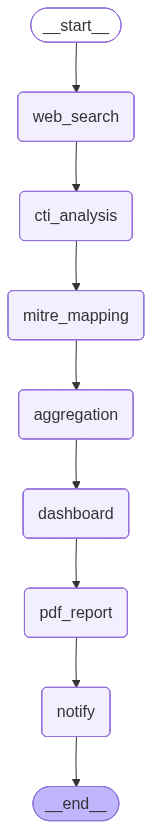

In [40]:
# Option 2 — PNG image (best looking, needs graphviz)
!pip install -q grandalf pygraphviz

from graph import build_pipeline
from IPython.display import Image

pipeline = build_pipeline()
img = pipeline.get_graph().draw_mermaid_png()

with open("graph_viz.png", "wb") as f:
    f.write(img)

Image("graph_viz.png")

In [41]:
import ast, pathlib

src = pathlib.Path("/kaggle/working/graph.py").read_text()
try:
    ast.parse(src)
    print("✅ graph.py syntax OK")
except SyntaxError as e:
    print(f"❌ Ligne {e.lineno}: {e.msg}")

✅ graph.py syntax OK


In [42]:
import os
print("Tracing active:", os.environ.get("LANGSMITH_TRACING"))
print("Project:", os.environ.get("LANGSMITH_PROJECT"))
print("Key set:", bool(os.environ.get("LANGSMITH_API_KEY")))
# Should print: True, cti_rag, True

Tracing active: true
Project: cti_rag
Key set: True


In [43]:
!pwd
!ls

/kaggle/working
aggregator.py	       faiss_cti_index	     __notebook__.ipynb
config.py	       faiss_cti_index.zip   notify_agent.py
cti_analysis_agent.py  graph.py		     pdf_report.py
cti_report.pdf	       graph_viz.png	     prioritizer.py
dashboard.png	       __init__.py	     __pycache__
dashboard.py	       llm_helper.py	     rag_search.py
detect_behaviors.py    mitigation_engine.py  report_generator.py
detect_patterns.py     mitre_agent.py	     severity_engine.py
extract_entities.py    mitre_mapper.py	     web_search_agent.py


In [44]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("HF_TOKEN")


In [45]:
!pip install -q feedparser beautifulsoup4

In [46]:
!ls

aggregator.py	       faiss_cti_index	     __notebook__.ipynb
config.py	       faiss_cti_index.zip   notify_agent.py
cti_analysis_agent.py  graph.py		     pdf_report.py
cti_report.pdf	       graph_viz.png	     prioritizer.py
dashboard.png	       __init__.py	     __pycache__
dashboard.py	       llm_helper.py	     rag_search.py
detect_behaviors.py    mitigation_engine.py  report_generator.py
detect_patterns.py     mitre_agent.py	     severity_engine.py
extract_entities.py    mitre_mapper.py	     web_search_agent.py


In [47]:
import importlib
import pdf_report
import graph
importlib.reload(pdf_report)
importlib.reload(graph)

from graph import run_pipeline
from IPython.display import FileLink

# Final attempt - let's go!
state = run_pipeline([
    "LockBit 3.0 ransomware targeting European banks."
])

print(f"✅ Success! Report Severity: {state['aggregated_report']['global_severity']}")
display(FileLink("cti_report.pdf"))

✅ LangSmith tracing enabled → project: cti_rag

🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 
  LAUNCHING MULTI-AGENT CTI PIPELINE
🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 


🌐 [NODE 0] Web Search Agent
🌐 Web Search Agent running...


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✅ Web Search Agent returned 15 messages
  ✅ Fetched 15 messages from web sources

🔍 [NODE 1] CTI Analysis Agent
  Analysing message 1/16 …
[Step 1] Extracting entities...


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- QWEN RESPONSE ---
{
    "new_malware": ["LockBit 3.0"],
    "threat_actors": [],
    "defanged_iocs": [],
    "campaign_names": [],
    "targeted_sectors": ["financial institutions"],
    "targeted_countries": ["Europe"],
    "tools_abused": [],
    "additional_cves": [],
    "context_notes": "The LockBit 3.0 ransomware variant targets European financial institutions."
}
-------------------
[Step 2] Detecting behaviors...


...

Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- QWEN RESPONSE ---
```json
{
  "adj": [
    {"id": "T1071", "imp": 2.0, "exp": 4.0, "pre": 1.0, "ste": 3.0, "res": "This technique involves exploiting vulnerabilities in application layer protocols to gain unauthorized access or control over a system."},
    {"id": "T1573", "imp": 3.0, "exp": 5.0, "pre": 2.0, "ste": 4.0, "res": "This technique uses encrypted channels to bypass network security measures and communicate with internal systems without detection."},
    {"id": "T1571", "imp": 2.0, "exp": 4.0, "pre": 1.0, "ste": 3.0, "res": "This technique exploits non-standard ports to establish connections that are not monitored by common intrusion detection systems (IDS)."}
  ],
  "bonus": 0.0,
  "reason": "The provided techniques involve various aspects of cyber attacks such as protocol exploitation, encryption bypass, and port scanning, which can be used to create logical attack paths."
}
```
-------------------
[Step 3] Recommending mitigations...

--- QWEN RESPONSE ---
```json
{
 

INFO:root:📢 Notify Agent started
INFO:root:🔑 BREVO_API_KEY loaded: True
INFO:root:📧 EMAIL_SENDER loaded: chayma.dallel@enis.tn
INFO:root:✅ Brevo status: 401



✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ 
  PIPELINE COMPLETE
✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ 
  📄 PDF   : /kaggle/working/cti_report.pdf
  📈 Dash  : dashboard.png
  📢 Alerts: 0
✅ Success! Report Severity: High


/kaggle/working/cti_report.pdf

In [48]:

import json, os

OUTPUT_DIR = "/kaggle/working/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

with open(f"{OUTPUT_DIR}/pipeline_output.json", "w", encoding="utf-8") as f:
    json.dump(state, f, indent=4, ensure_ascii=False)

print("✅ Output enregistré")


✅ Output enregistré


In [49]:
!pwd
!ls

/kaggle/working
aggregator.py	       faiss_cti_index.zip   outputs
config.py	       graph.py		     pdf_report.py
cti_analysis_agent.py  graph_viz.png	     prioritizer.py
cti_report.pdf	       __init__.py	     __pycache__
dashboard.png	       llm_helper.py	     rag_search.py
dashboard.py	       mitigation_engine.py  report_generator.py
detect_behaviors.py    mitre_agent.py	     severity_engine.py
detect_patterns.py     mitre_mapper.py	     web_search_agent.py
extract_entities.py    __notebook__.ipynb
faiss_cti_index        notify_agent.py


In [50]:
import requests

user_secrets = UserSecretsClient()
from kaggle_secrets import UserSecretsClient
SENDER_EMAIL =user_secrets.get_secret("EMAIL_SENDER")
BREVO_API_KEY =user_secrets.get_secret("BREVO_API_KEY")
response = requests.post(
    "https://api.brevo.com/v3/smtp/email",
    headers={
        "api-key":BREVO_API_KEY,
        "Content-Type": "application/json"
    },
    json={
        "sender": {
            "name": "Notify Agent",
            "email": SENDER_EMAIL
        },
        "to": [
            {"email": "cdallel9@gmail.com"}
        ],
        "subject": "Notification de sécurité – Rapport automatique",
        "htmlContent": """
        <p>Bonjour,</p>
        <p>Un rapport de cybersécurité a été analysé automatiquement.</p>
        <p>Ceci est une notification envoyée depuis Kaggle.</p>
        <p>Cordialement,<br><b>Notify Agent</b></p>
        """
    }
)

print("Status:", response.status_code)
print("Response:", response.text)
print("it works !")

Status: 401
Response: {"message":"Key not found","code":"unauthorized"}

it works !


In [51]:
!pip install -q fastapi uvicorn[standard] slowapi pydantic httpx pytest pytest-asyncio

In [52]:
%%writefile /kaggle/working/schemas.py
from pydantic import BaseModel, Field
from typing import Optional
from datetime import datetime

class AnalyzeRequest(BaseModel):
    messages: list[str] = Field(..., min_length=1, description="Raw CTI messages")
    notify: bool = Field(default=False, description="Send email when done")

class PipelineResponse(BaseModel):
    job_id: str
    status: str
    global_severity: Optional[str] = None
    techniques_count: Optional[int] = None
    pdf_path: Optional[str] = None
    dashboard_path: Optional[str] = None
    alerts_sent: Optional[int] = None
    error: Optional[str] = None
    created_at: datetime

class HealthResponse(BaseModel):
    status: str
    version: str
    langsmith_tracing: bool
    working_dir: str

Writing /kaggle/working/schemas.py


In [53]:
%%writefile /kaggle/working/api_auth.py
from fastapi import Security, HTTPException, status
from fastapi.security import APIKeyHeader
from slowapi import Limiter
from slowapi.util import get_remote_address

# In production: load these from environment variables or a database
API_KEYS = {
    "cti-key-analyst-001": "analyst",
    "cti-key-admin-001":   "admin",
}

api_key_header = APIKeyHeader(name="X-API-Key", auto_error=False)
limiter = Limiter(key_func=get_remote_address)

async def require_api_key(api_key: str = Security(api_key_header)):
    if not api_key or api_key not in API_KEYS:
        raise HTTPException(
            status_code=status.HTTP_403_FORBIDDEN,
            detail="Invalid or missing API key. Pass it as header: X-API-Key"
        )
    return {"key": api_key, "role": API_KEYS[api_key]}

Writing /kaggle/working/api_auth.py


In [54]:
%%writefile /kaggle/working/main.py
import os
import sys
import uuid
from datetime import datetime, timezone
from contextlib import asynccontextmanager

# ── Ensure local modules are importable ──────────────────────
sys.path.insert(0, "/kaggle/working")
os.chdir("/kaggle/working")

from fastapi import FastAPI, Depends, BackgroundTasks, HTTPException, Request
from fastapi.responses import FileResponse
from slowapi import _rate_limit_exceeded_handler
from slowapi.errors import RateLimitExceeded

from api_auth import require_api_key, limiter
from schemas import AnalyzeRequest, PipelineResponse, HealthResponse

# ── In-memory job store ───────────────────────────────────────
# Replace with Redis or a DB for production
jobs: dict[str, dict] = {}


# ── Background worker ─────────────────────────────────────────
def _run_pipeline_sync(job_id: str, messages: list[str], notify: bool):
    try:
        from graph import run_pipeline
        state = run_pipeline(messages)

        jobs[job_id].update({
            "status":           "complete",
            "global_severity":  state["aggregated_report"].get("global_severity"),
            "techniques_count": state["aggregated_report"]
                                     .get("statistics", {})
                                     .get("total_techniques", 0),
            "pdf_path":         state.get("pdf_path"),
            "dashboard_path":   state.get("dashboard_path"),
            "alerts_sent":      state.get("alertes_envoyees", 0),
        })
    except Exception as e:
        jobs[job_id].update({"status": "failed", "error": str(e)})


# ── Lifespan (startup / shutdown) ────────────────────────────
@asynccontextmanager
async def lifespan(app: FastAPI):
    # Set LangSmith env vars before any langchain import
    os.environ.setdefault("LANGSMITH_TRACING",  "true")
    os.environ.setdefault("LANGSMITH_ENDPOINT", "https://api.smith.langchain.com")
    os.environ.setdefault("LANGSMITH_PROJECT",  "cti_rag")
    print("✅ CTI API started")
    yield
    print("CTI API shut down")


# ── App ───────────────────────────────────────────────────────
app = FastAPI(
    title="CTI Threat Intelligence API",
    description="""
Multi-agent CTI pipeline exposing:
- **POST /analyze** — submit messages, get a job_id back immediately
- **GET  /report/{job_id}** — poll for results
- **GET  /report/{job_id}/pdf** — download the PDF report
- **GET  /health** — liveness check
    """,
    version="1.0.0",
    lifespan=lifespan,
)

app.state.limiter = limiter
app.add_exception_handler(RateLimitExceeded, _rate_limit_exceeded_handler)


# ── Routes ────────────────────────────────────────────────────

@app.get(
    "/health",
    response_model=HealthResponse,
    tags=["system"],
    summary="Liveness check",
)
def health():
    return {
        "status":            "ok",
        "version":           "1.0.0",
        "langsmith_tracing": os.environ.get("LANGSMITH_TRACING") == "true",
        "working_dir":       os.getcwd(),
    }


@app.post(
    "/analyze",
    response_model=PipelineResponse,
    tags=["pipeline"],
    summary="Submit CTI messages for analysis",
    responses={
        403: {"description": "Invalid API key"},
        429: {"description": "Rate limit exceeded (5 req/min)"},
    },
)
@limiter.limit("5/minute")
async def analyze(
    request: Request,
    body: AnalyzeRequest,
    background_tasks: BackgroundTasks,
    user=Depends(require_api_key),
):
    job_id = str(uuid.uuid4())
    jobs[job_id] = {
        "status":     "running",
        "created_at": datetime.now(timezone.utc),
    }
    background_tasks.add_task(
        _run_pipeline_sync, job_id, body.messages, body.notify
    )
    return PipelineResponse(
        job_id=job_id,
        status="running",
        created_at=jobs[job_id]["created_at"],
    )


@app.get(
    "/report/{job_id}",
    response_model=PipelineResponse,
    tags=["pipeline"],
    summary="Poll pipeline results",
)
def get_report(job_id: str, user=Depends(require_api_key)):
    if job_id not in jobs:
        raise HTTPException(status_code=404, detail=f"Job '{job_id}' not found")
    job = jobs[job_id]
    return PipelineResponse(
        job_id=job_id,
        created_at=job["created_at"],
        status=job.get("status", "unknown"),
        global_severity=job.get("global_severity"),
        techniques_count=job.get("techniques_count"),
        pdf_path=job.get("pdf_path"),
        dashboard_path=job.get("dashboard_path"),
        alerts_sent=job.get("alerts_sent"),
        error=job.get("error"),
    )


@app.get(
    "/report/{job_id}/pdf",
    tags=["pipeline"],
    summary="Download the generated PDF report",
    responses={
        404: {"description": "Job not found or PDF not ready yet"},
    },
)
def download_pdf(job_id: str, user=Depends(require_api_key)):
    if job_id not in jobs:
        raise HTTPException(status_code=404, detail="Job not found")
    pdf = jobs[job_id].get("pdf_path")
    if not pdf or not os.path.exists(pdf):
        raise HTTPException(status_code=404, detail="PDF not ready yet — poll /report/{job_id} first")
    return FileResponse(pdf, media_type="application/pdf", filename="cti_report.pdf")


@app.get(
    "/jobs",
    tags=["system"],
    summary="List all jobs (admin only)",
)
def list_jobs(user=Depends(require_api_key)):
    if user["role"] != "admin":
        raise HTTPException(status_code=403, detail="Admin role required")
    return {
        jid: {
            "status":     j.get("status"),
            "severity":   j.get("global_severity"),
            "created_at": j.get("created_at"),
        }
        for jid, j in jobs.items()
    }

Writing /kaggle/working/main.py


In [55]:
import sys, os, threading, uvicorn, time

sys.path.insert(0, "/kaggle/working")
os.chdir("/kaggle/working")

# Kill any previous server on port 8000
import socket
def port_in_use(port):
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        return s.connect_ex(("localhost", port)) == 0

if port_in_use(8000):
    print("⚠️  Port 8000 already in use — restart kernel if tests fail")
else:
    config = uvicorn.Config(
        "main:app",
        host="0.0.0.0",
        port=8000,
        log_level="info",
    )
    server = uvicorn.Server(config)
    thread = threading.Thread(target=server.run, daemon=True)
    thread.start()

    for _ in range(20):
        time.sleep(1)
        if server.started:
            print("✅ Server ready")
            print("   http://localhost:8000/docs  ← Swagger UI")
            print("   http://localhost:8000/redoc ← ReDoc")
            break
    else:
        print("❌ Server did not start — check errors above")

INFO:     Started server process [23]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


✅ CTI API started
✅ Server ready
   http://localhost:8000/docs  ← Swagger UI
   http://localhost:8000/redoc ← ReDoc


In [56]:
import requests, time

BASE    = "http://localhost:8000"
HEADERS = {"X-API-Key": "cti-key-analyst-001"}
ADMIN   = {"X-API-Key": "cti-key-admin-001"}

# 1. Health
r = requests.get(f"{BASE}/health")
print("Health:", r.json())

# 2. Reject bad key
r = requests.get(f"{BASE}/health", headers={"X-API-Key": "wrong"})
print("Bad key (should be 403):", r.status_code)  # no /health auth, so test on /jobs
r = requests.get(f"{BASE}/jobs", headers={"X-API-Key": "wrong"})
print("Bad key on /jobs:", r.status_code)          # 403

# 3. Submit a job
r = requests.post(
    f"{BASE}/analyze",
    headers=HEADERS,
    json={"messages": ["LockBit 3.0 ransomware targeting European banks."], "notify": False},
)
print("Submit:", r.json())
job_id = r.json()["job_id"]

# 4. Poll until done
print("\nPolling...")
for _ in range(60):
    time.sleep(5)
    r = requests.get(f"{BASE}/report/{job_id}", headers=HEADERS)
    result = r.json()
    print(f"  status={result['status']}  severity={result.get('global_severity')}")
    if result["status"] in ("complete", "failed"):
        print("\nFinal result:", result)
        break

# 5. List jobs (admin only)
r = requests.get(f"{BASE}/jobs", headers=ADMIN)
print("\nAll jobs:", r.json())

# 6. List jobs as analyst (should be 403)
r = requests.get(f"{BASE}/jobs", headers=HEADERS)
print("Analyst on /jobs (should be 403):", r.status_code)

INFO:     127.0.0.1:41806 - "GET /health HTTP/1.1" 200 OK
Health: {'status': 'ok', 'version': '1.0.0', 'langsmith_tracing': True, 'working_dir': '/kaggle/working'}
INFO:     127.0.0.1:41816 - "GET /health HTTP/1.1" 200 OK
Bad key (should be 403): 200
INFO:     127.0.0.1:41820 - "GET /jobs HTTP/1.1" 403 Forbidden
Bad key on /jobs: 403
INFO:     127.0.0.1:41834 - "POST /analyze HTTP/1.1" 200 OK

🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 
  LAUNCHING MULTI-AGENT CTI PIPELINE
🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 


🌐 [NODE 0] Web Search Agent
Submit: {'job_id': '83f109a8-07f3-4f2e-aa73-c7f18ee4afc8', 'status': 'running', 'global_severity': None, 'techniques_count': None, 'pdf_path': None, 'dashboard_path': None, 'alerts_sent': None, 'error': None, 'created_at': '2026-04-21T01:17:47.798514Z'}

Polling...
🌐 Web Search Agent running...
INFO:     127.0.0.1:41842 - "GET /report/83f109a8-07f3-4f2e-aa73-c7f18ee4afc8 HTTP/1.1" 200 OK
  status=running  severity=None
INFO:     127.0.0.1:36528 - "GE

Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✅ Web Search Agent returned 19 messages
  ✅ Fetched 19 messages from web sources

🔍 [NODE 1] CTI Analysis Agent
  Analysing message 1/20 …
[Step 1] Extracting entities...
INFO:     127.0.0.1:36532 - "GET /report/83f109a8-07f3-4f2e-aa73-c7f18ee4afc8 HTTP/1.1" 200 OK
  status=running  severity=None


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- QWEN RESPONSE ---
{
    "new_malware": ["LockBit 3.0"],
    "threat_actors": [],
    "defanged_iocs": [],
    "campaign_names": [],
    "targeted_sectors": ["financial institutions"],
    "targeted_countries": ["Europe"],
    "tools_abused": [],
    "additional_cves": [],
    "context_notes": "The LockBit 3.0 ransomware variant targets European financial institutions."
}
-------------------
[Step 2] Detecting behaviors...


...


--- QWEN RESPONSE ---
{
    "new_malware": [],
    "threat_actors": [],
    "defanged_iocs": [],
    "campaign_names": [],
    "targeted_sectors": [],
    "targeted_countries": [],
    "tools_abused": ["FastAPI", "background workers"],
    "additional_cves": [],
    "context_notes": "The summary mentions Python, security, and antivirus but does not provide specific details about new malware, threat actors, defanged IOEs, campaign names, targeted sectors/countries, tools abused, or additional CVEs."
}
-------------------
[Step 2] Detecting behaviors...


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- QWEN RESPONSE ---
```json
{
    "behaviors": [],
    "attack_chain_summary": "",
    "novel_techniques": []
}
```
-------------------
[Step 3] Detecting patterns...
INFO:     127.0.0.1:54118 - "GET /report/83f109a8-07f3-4f2e-aa73-c7f18ee4afc8 HTTP/1.1" 200 OK
  status=running  severity=None


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- QWEN RESPONSE ---
```json
{
    "threat_classification": "ADMINISTRATIVE",
    "is_malicious": false,
    "confidence": 1.0,
    "emerging_terms": [],
    "correlated_patterns": [
        {
            "keywords": ["real-time", "file-scanning", "FastAPI", "background-workers"],
            "attack_pattern": []
        }
    ],
    "predicted_next_steps": ["None"],
    "flagged_jargon": [],
    "semantic_summary": "This message discusses implementing real-time file scanning using FastAPI and background workers, which is a common administrative task."
}
```
-------------------
[Step 4] Searching RAG database...
[✅] CTI Analysis complete.
  Analysing message 16/20 …
[Step 1] Extracting entities...
INFO:     127.0.0.1:54128 - "GET /report/83f109a8-07f3-4f2e-aa73-c7f18ee4afc8 HTTP/1.1" 200 OK
  status=running  severity=None
INFO:     127.0.0.1:51234 - "GET /report/83f109a8-07f3-4f2e-aa73-c7f18ee4afc8 HTTP/1.1" 200 OK
  status=running  severity=None
INFO:     127.0.0.1:51244 - "GET /job

In [57]:
from IPython.display import IFrame
IFrame("http://localhost:8000/docs", width=900, height=600)

In [58]:
!pip install -q pyngrok


--- QWEN RESPONSE ---
{
    "new_malware": [],
    "threat_actors": [],
    "defanged_iocs": [],
    "campaign_names": [],
    "targeted_sectors": [],
    "targeted_countries": [],
    "tools_abused": ["OpenSSL", "GnuPG", "LibTomCrypt"],
    "additional_cves": [],
    "context_notes": "The summary mentions'security', but does not provide any specific new malware, threat actors, defanged IOEs, campaign names, targeted sectors/countries, tools abused, additional CVEs, or context notes."
}
-------------------
[Step 2] Detecting behaviors...


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- QWEN RESPONSE ---
```json
{
    "behaviors": [],
    "attack_chain_summary": "",
    "novel_techniques": []
}
```
-------------------
[Step 3] Detecting patterns...


In [59]:
import sys, os, threading, uvicorn, time
from pyngrok import ngrok
from kaggle_secrets import UserSecretsClient

sys.path.insert(0, "/kaggle/working")
os.chdir("/kaggle/working")

# ── Configurer ngrok ──────────────────────────────────────────
ngrok_token = UserSecretsClient().get_secret("NGROK_TOKEN")
ngrok.set_auth_token(ngrok_token)

# ── Démarrer FastAPI dans un thread ───────────────────────────
config = uvicorn.Config("main:app", host="0.0.0.0", port=8000, log_level="warning")
server = uvicorn.Server(config)
thread = threading.Thread(target=server.run, daemon=True)
thread.start()

# Attendre que le serveur soit prêt
for _ in range(20):
    time.sleep(1)
    if server.started:
        break

# ── Ouvrir le tunnel ngrok ────────────────────────────────────
tunnel = ngrok.connect(8000)
public_url = tunnel.public_url

print(f"✅ API publique   : {public_url}")
print(f"📖 Swagger docs  : {public_url}/docs")
print(f"📖 ReDoc         : {public_url}/redoc")
print(f"❤️  Health check  : {public_url}/health")

INFO:pyngrok.process:Updating authtoken for default "config_path" of "ngrok_path": /root/.config/ngrok/ngrok
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use


✅ CTI API started
CTI API shut down


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- QWEN RESPONSE ---
```json
{
    "threat_classification": "ADMINISTRATIVE",
    "is_malicious": false,
    "confidence": 1.0,
    "emerging_terms": [],
    "correlated_patterns": [],
    "predicted_next_steps": ["Scheduled System Update"],
    "flagged_jargon": [],
    "semantic_summary": "This message appears to be a routine announcement about recommended open-source tools for generating a Cryptographic Bill of Materials (CBOM). It does not contain any indicators of malicious activity."
}
```
-------------------
[Step 4] Searching RAG database...
[✅] CTI Analysis complete.
  Analysing message 17/20 …
[Step 1] Extracting entities...


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- QWEN RESPONSE ---
```json
{
    "behaviors": [],
    "attack_chain_summary": "The attackers created fake cryptocurrency wallet apps that lure users into downloading them from the App Store. Once installed, these apps redirect users to phishing sites where they can be tricked into revealing their recovery phrases and private keys.",
    "novel_techniques": []
}
```
-------------------
[Step 3] Detecting patterns...


INFO:pyngrok.ngrok:Opening tunnel named: http-8000-2054759a-c844-423c-843a-b7f4417d50ff
INFO:pyngrok.process.ngrok:t=2026-04-21T01:23:11+0000 lvl=info msg="no configuration paths supplied"
INFO:pyngrok.process.ngrok:t=2026-04-21T01:23:11+0000 lvl=info msg="using configuration at default config path" path=/root/.config/ngrok/ngrok.yml
INFO:pyngrok.process.ngrok:t=2026-04-21T01:23:11+0000 lvl=info msg="open config file" path=/root/.config/ngrok/ngrok.yml err=nil
INFO:pyngrok.process.ngrok:t=2026-04-21T01:23:11+0000 lvl=info msg="FIPS 140 mode" enabled=false
INFO:pyngrok.process.ngrok:t=2026-04-21T01:23:11+0000 lvl=info msg="starting web service" obj=web addr=127.0.0.1:4040 allow_hosts=[]
INFO:pyngrok.process.ngrok:t=2026-04-21T01:23:11+0000 lvl=info msg="client session established" obj=tunnels.session
INFO:pyngrok.process.ngrok:t=2026-04-21T01:23:11+0000 lvl=info msg="tunnel session started" obj=tunnels.session
INFO:pyngrok.process.ngrok:t=2026-04-21T01:23:11+0000 lvl=info msg=start pg=/

✅ API publique   : https://handheld-antihero-framing.ngrok-free.dev
📖 Swagger docs  : https://handheld-antihero-framing.ngrok-free.dev/docs
📖 ReDoc         : https://handheld-antihero-framing.ngrok-free.dev/redoc
❤️  Health check  : https://handheld-antihero-framing.ngrok-free.dev/health


INFO:pyngrok.process.ngrok:t=2026-04-21T01:23:12+0000 lvl=info msg=end pg=/api/tunnels id=f91d57f1405a1716 status=201 dur=281.03741ms


In [60]:
import requests

BASE    = public_url
HEADERS = {"X-API-Key": "cti-key-analyst-001"}

# Health
r = requests.get(f"{BASE}/health")
print("Health:", r.json())

# Soumettre un job
r = requests.post(
    f"{BASE}/analyze",
    headers=HEADERS,
    json={"messages": ["LockBit 3.0 ransomware targeting European banks."], "notify": False}
)
print("Job:", r.json())
job_id = r.json()["job_id"]

# Polling
for _ in range(60):
    time.sleep(5)
    r = requests.get(f"{BASE}/report/{job_id}", headers=HEADERS)
    result = r.json()
    print(f"  status={result['status']}  severity={result.get('global_severity')}")
    if result["status"] in ("complete", "failed"):
        break

INFO:pyngrok.process.ngrok:t=2026-04-21T01:23:12+0000 lvl=info msg="join connections" obj=join id=3789177f1654 l=127.0.0.1:8000 r=35.226.47.23:37432
INFO:pyngrok.process.ngrok:t=2026-04-21T01:23:12+0000 lvl=info msg="join connections" obj=join id=e4c1f1a6be82 l=127.0.0.1:8000 r=35.226.47.23:40024


Health: {'status': 'ok', 'version': '1.0.0', 'langsmith_tracing': True, 'working_dir': '/kaggle/working'}

🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 
  LAUNCHING MULTI-AGENT CTI PIPELINE
🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 


🌐 [NODE 0] Web Search Agent
🌐 Web Search Agent running...
Job: {'job_id': '2b174a8e-5b79-4e4b-932b-703f39266c7c', 'status': 'running', 'global_severity': None, 'techniques_count': None, 'pdf_path': None, 'dashboard_path': None, 'alerts_sent': None, 'error': None, 'created_at': '2026-04-21T01:23:12.503110Z'}


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- QWEN RESPONSE ---
```json
{
    "threat_classification": "MALICIOUS",
    "is_malicious": true,
    "confidence": 1.0,
    "emerging_terms": [
        "fakewallet",
        "crypto",
        "stealer",
        "spreading",
        "phishing",
        "App Store",
        "Apple"
    ],
    "correlated_patterns": [
        {
            "keywords": ["FakeWallet", "crypto", "stealer", "spreading"],
            "attack_pattern": "Phishing Application Distribution"
        }
    ],
    "predicted_next_steps": ["Monitor App Store activity closely", "Alert security team about potential threats"],
    "flagged_jargon": [],
    "semantic_summary": "A fake cryptocurrency wallet application was found in the Apple App Store, posing as legitimate apps but with malicious intent."
}
```
-------------------
[Step 4] Searching RAG database...
[✅] CTI Analysis complete.
  Analysing message 18/20 …
[Step 1] Extracting entities...


INFO:pyngrok.process.ngrok:t=2026-04-21T01:23:17+0000 lvl=info msg="join connections" obj=join id=c98648e9357d l=127.0.0.1:8000 r=35.226.47.23:58852


...


--- QWEN RESPONSE ---
```json
{
    "new_malware": [],
    "threat_actors": [],
    "defanged_iocs": [],
    "campaign_names": [],
    "targeted_sectors": [],
    "targeted_countries": [],
    "tools_abused": ["xmlhttprequest"],
    "additional_cves": [],
    "context_notes": "The question discusses JavaScript security issues related to the `responseXML` property of `XMLHttpRequest`. No specific threats or actors were identified."
}
```
-------------------
[Step 2] Detecting behaviors...


INFO:pyngrok.process.ngrok:t=2026-04-21T01:28:13+0000 lvl=info msg="join connections" obj=join id=f966da1f6711 l=127.0.0.1:8000 r=35.226.47.23:49426
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  status=running  severity=None

--- QWEN RESPONSE ---
```json
{
    "behaviors": [],
    "attack_chain_summary": "",
    "novel_techniques": []
}
```
-------------------
[Step 3] Detecting patterns...


INFO:pyngrok.process.ngrok:t=2026-04-21T01:28:18+0000 lvl=info msg="join connections" obj=join id=73f2a75cd51e l=127.0.0.1:8000 r=35.226.47.23:36952


  status=running  severity=None


In [61]:
from IPython.display import IFrame
IFrame(f"{public_url}/docs", width=900, height=600)

In [62]:
ngrok.disconnect(tunnel.public_url)
ngrok.kill()
print("Tunnel fermé")

INFO:pyngrok.ngrok:Disconnecting tunnel: https://handheld-antihero-framing.ngrok-free.dev
INFO:pyngrok.process.ngrok:t=2026-04-21T01:28:19+0000 lvl=info msg=start pg=/api/tunnels/http-8000-2054759a-c844-423c-843a-b7f4417d50ff id=70f952b6c8889456
INFO:pyngrok.process.ngrok:t=2026-04-21T01:28:19+0000 lvl=info msg=end pg=/api/tunnels/http-8000-2054759a-c844-423c-843a-b7f4417d50ff id=70f952b6c8889456 status=204 dur=18.562729ms
INFO:pyngrok.process:Killing ngrok process: 956
INFO:pyngrok.process.ngrok:t=2026-04-21T01:28:19+0000 lvl=info msg="failed to accept connection: Listener closed" obj=tunnels.session clientid=08df918afa9636c48b1c06493519794b
INFO:pyngrok.process.ngrok:t=2026-04-21T01:28:19+0000 lvl=info msg="Error handling the forwarder accept error" error="no tunnel found with requested name"


Tunnel fermé
